# LeafletFA Splicing Analysis - Mouse Foundation Model
 
### This notebook analyzes the relationship between splicing factors (LeafletFA) and gene expression factors (scVI, NMF, PCA) for age prediction across different cell types.


## 1. Setup and Imports

In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from pathlib import Path
import os
import sys
from collections import defaultdict

# Statistical libraries
from scipy.stats import spearmanr, pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy import stats
import scipy.sparse as sp
from statsmodels.stats.multitest import multipletests

# Machine learning
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Specialized libraries
import scanpy as sc
from adjustText import adjust_text
from tqdm import tqdm

## 2. Configuration and Path Setup

In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

class Config:
    # Base directories
    BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
    RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"
    
    # Data paths
    GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_latent_20_2025-08-04.h5ad"
    GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_standard_20_1024_2025-08-03.h5ad"
    
    # GSEA paths
    GSEA_BASE_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250804"
    
    # Reference files
    AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
    RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"
    ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
    
    # Main parameters to change
    MODEL_TRAIN_DATE = "2025-07-30"
    MODEL_ANALYSIS_DATE = "2025-07-31"
    PARAM_ID = 0
    
    # Genome database
    MOUSE_DB_FILE = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"

# Generate auto paths
def setup_paths(config):
    """Generate all necessary paths from configuration."""
    param_results_dir = f"{config.RESULTS_BASE_DIR}/{config.MODEL_TRAIN_DATE}/{config.MODEL_ANALYSIS_DATE}/param_id_{config.PARAM_ID}"
    data_dir = f"{param_results_dir}/data"
    model_outputs_dir = f"{config.BASE_DIR}/Leaflet/leafletFAmodel/{config.MODEL_TRAIN_DATE}"
    output_dir = f"{param_results_dir}/analysis_outputs"
    
    paths = {
        'data_dir': data_dir,
        'output_dir': output_dir,
        'splice_adata_path': f"{data_dir}/splice_adata_PHI_psi_var_obs.h5ad",
        'pi_values_path': f"{data_dir}/PI_values.npy",
        'perplexity_path': f"{data_dir}/cell_metadata_with_perplexity_param_id_{config.PARAM_ID}.csv.gz",
        'diff_spl_path': f"{data_dir}/differential_splicing_results.csv",
        'model_path': f"{model_outputs_dir}/run_{config.PARAM_ID}/leafletfa_model.pkl.xz"
    }
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    return paths

config = Config()
paths = setup_paths(config)

print(f"Configuration set for param_id {config.PARAM_ID}")
print(f"Output directory: {paths['output_dir']}")

Configuration set for param_id 0
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs


## 3. Custom Module Imports

In [3]:
# Import LeafletFA differential splicing code
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
utils_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

if src_path not in sys.path:
    sys.path.append(src_path)
if utils_path not in sys.path:
    sys.path.append(utils_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds
from utils import *
from figure_plotting import *
from atse_viz import *
import gffutils

# Load genome database
db_mouse = gffutils.FeatureDB(config.MOUSE_DB_FILE, keep_order=True)

# Import LeafletFA differential splicing code
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
utils_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

if src_path not in sys.path:
    sys.path.append(src_path)
if utils_path not in sys.path:
    sys.path.append(utils_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds
from utils import *
from figure_plotting import *
from atse_viz import *
import gffutils

# Load genome database
db_mouse = gffutils.FeatureDB(config.MOUSE_DB_FILE, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


## 4. Data Loading Functions

In [4]:
def load_gsea_data(base_path):
    """Load all GSEA data files."""
    gsea_data = {}
    
    methods = ['scvi'] #, 'nmf', 'pca']
    for method in methods:
        gsea_data[method] = {
            'full': pd.read_csv(f"{base_path}/gsea_results_comprehensive_{method}.tsv.gz", sep="\t")
        }
    
    return gsea_data

def load_reference_genes(aging_genes_path, rbp_file_path):
    """Load aging genes and RBP genes."""
    aging_genes_mouse, aging_genes_human = load_aging_genes(aging_genes_path)
    rbps = load_rbp_genes(rbp_file_path)
    
    # Process gene names
    rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
    aging_genes_mouse = [g.upper() for g in aging_genes_mouse]
    
    return aging_genes_mouse, rbps

def load_main_datasets(config, paths):
    """Load main AnnData objects and associated data."""
    print("Loading main datasets...")
    
    # Load gene expression data
    # ge_adata_nmf = ad.read_h5ad(config.GE_ANNDATA_NMF_PATH)
    ge_adata = ad.read_h5ad(config.GE_ANNDATA_scVI_PATH)
    
    # Combine data
    # assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell ID mismatch"
    # assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene name mismatch"
    
    # ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
    # ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]
    # ge_adata.obsm["X_pca"] = ge_adata_nmf.obsm["X_pca"]
    # ge_adata.varm["pca_loadings"] = ge_adata_nmf.varm["pca_loadings"]
    
    # Add gene names if missing
    if "gene_name" not in ge_adata.var.columns:
        ge_adata.var["gene_name"] = ge_adata.var_names
    if "cell_id" not in ge_adata.obs.columns:
        ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
    
    # Load splicing data
    splice_adata = ad.read_h5ad(paths['splice_adata_path'])
    pi = np.load(paths['pi_values_path'])
    diff_spl = pd.read_csv(paths['diff_spl_path'])
    perplexity_df = pd.read_csv(paths['perplexity_path']).set_index("cell_id")
    
    print(f"Loaded splice_adata: {splice_adata.shape}")
    print(f"Loaded ge_adata: {ge_adata.shape}")
    
    return ge_adata, splice_adata, pi, diff_spl, perplexity_df

## 5. Data Processing Functions

In [5]:
def process_splice_data(splice_adata, pi, diff_spl, perplexity_df):
    """Process and reorder splicing data based on PI values."""
    print("Processing splicing data...")
    
    # Fix sex column
    sex_str = splice_adata.obs["sex"].astype(str)
    sex_fixed = sex_str.replace({"M": "male", "F": "female"})
    splice_adata.obs["sex"] = pd.Categorical(sex_fixed)
    
    # Rename mouse.id to donor_id if exists
    if "mouse.id" in splice_adata.obs.columns:
        splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)
    
    # Add perplexity
    splice_adata.obs_names = splice_adata.obs["cell_id"]
    assert all(splice_adata.obs_names == perplexity_df.index), "Cell ID mismatch with perplexity"
    splice_adata.obs["perplexity"] = perplexity_df["perplexity"]
    
    # Reorder factors by PI values
    K = splice_adata.obsm["X_PHI"].shape[1]
    new_order = np.argsort(-pi)  # Descending order
    
    print("Factor reordering based on PI values:")
    for rank, idx in enumerate(new_order[:5]):  # Show top 5
        print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")
    
    # Create mapping
    old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
    
    # Reorder matrices
    splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]
    splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]
    
    # Add factor columns to obs
    phi_colnames = [f"SP_{i+1}" for i in range(K)]
    phi_df = pd.DataFrame(
        splice_adata.obsm["X_PHI"], 
        index=splice_adata.obs_names,
        columns=phi_colnames
    )
    splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)
    
    # Update differential splicing results
    diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
    diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)
    
    return splice_adata, diff_spl

def annotate_genes(ge_adata, aging_genes_mouse, rbps):
    """Annotate genes with aging and RBP information."""
    ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
    ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
    return ge_adata

def filter_cell_types(splice_adata, ge_adata, min_cells=50):
    """Filter to cell types with sufficient cells."""
    valid_medium_ct = (
        splice_adata.obs["medium_cell_type"]
        .value_counts()[lambda x: x >= min_cells]
        .index
    )
    
    print(f"Keeping {len(valid_medium_ct)} cell types with >= {min_cells} cells")
    
    splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()
    ge_adata = ge_adata[ge_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()
    
    assert np.all(ge_adata.obs_names == splice_adata.obs_names), "Cell order mismatch after filtering"
    
    return splice_adata, ge_adata

## 6. Main Data Loading and Processing

In [6]:
# Load GSEA data
print("Loading GSEA data...")
gsea_data = load_gsea_data(config.GSEA_BASE_PATH)

# Load reference genes
print("Loading reference genes...")
aging_genes_mouse, rbps = load_reference_genes(config.AGING_GENES_PATH, config.RBP_FILE_PATH)

# Load main datasets
ge_adata, splice_adata, pi, diff_spl, perplexity_df = load_main_datasets(config, paths)

# Process data
splice_adata, diff_spl = process_splice_data(splice_adata, pi, diff_spl, perplexity_df)
ge_adata = annotate_genes(ge_adata, aging_genes_mouse, rbps)

# Sync additional columns
assert all(splice_adata.obs_names == ge_adata.obs_names)
for col in ["AgingScore_unweighted", "total_counts", "nuclear_class_log_norm", "nuclear_score_log_norm"]:
    if col in ge_adata.obs.columns:
        splice_adata.obs[col] = ge_adata.obs[col]

# Filter cell types
splice_adata, ge_adata = filter_cell_types(splice_adata, ge_adata)

# Clean up cell type names
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()

print(f"Final data shapes - Splice: {splice_adata.shape}, GE: {ge_adata.shape}")

Loading GSEA data...
Loading reference genes...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Loading main datasets...
Loaded splice_adata: (137936, 35197)
Loaded ge_adata: (137936, 2482)
Processing splicing data...
Factor reordering based on PI values:
Rank 1: Factor 2 → PI = 0.1451
Rank 2: Factor 0 → PI = 0.1417
Rank 3: Factor 1 → PI = 0.1131
Rank 4: Factor 6 → PI = 0.0708
Rank 5: Factor 12 → PI = 0.0475
Keeping 57 cell types with >= 50 cells
Final data shapes - Splice: (137893, 35197), GE: (137893, 2482)


## 7. Exploratory Data Analysis

Creating age vs cell type heatmap...


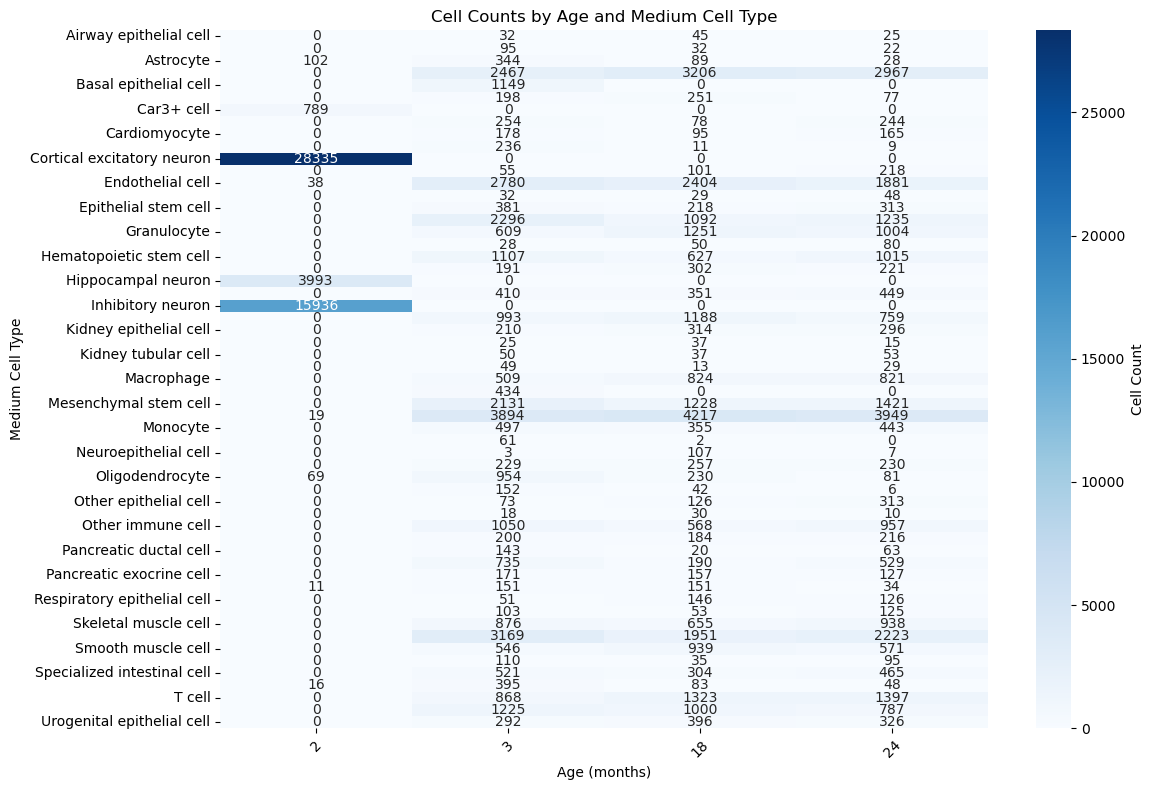

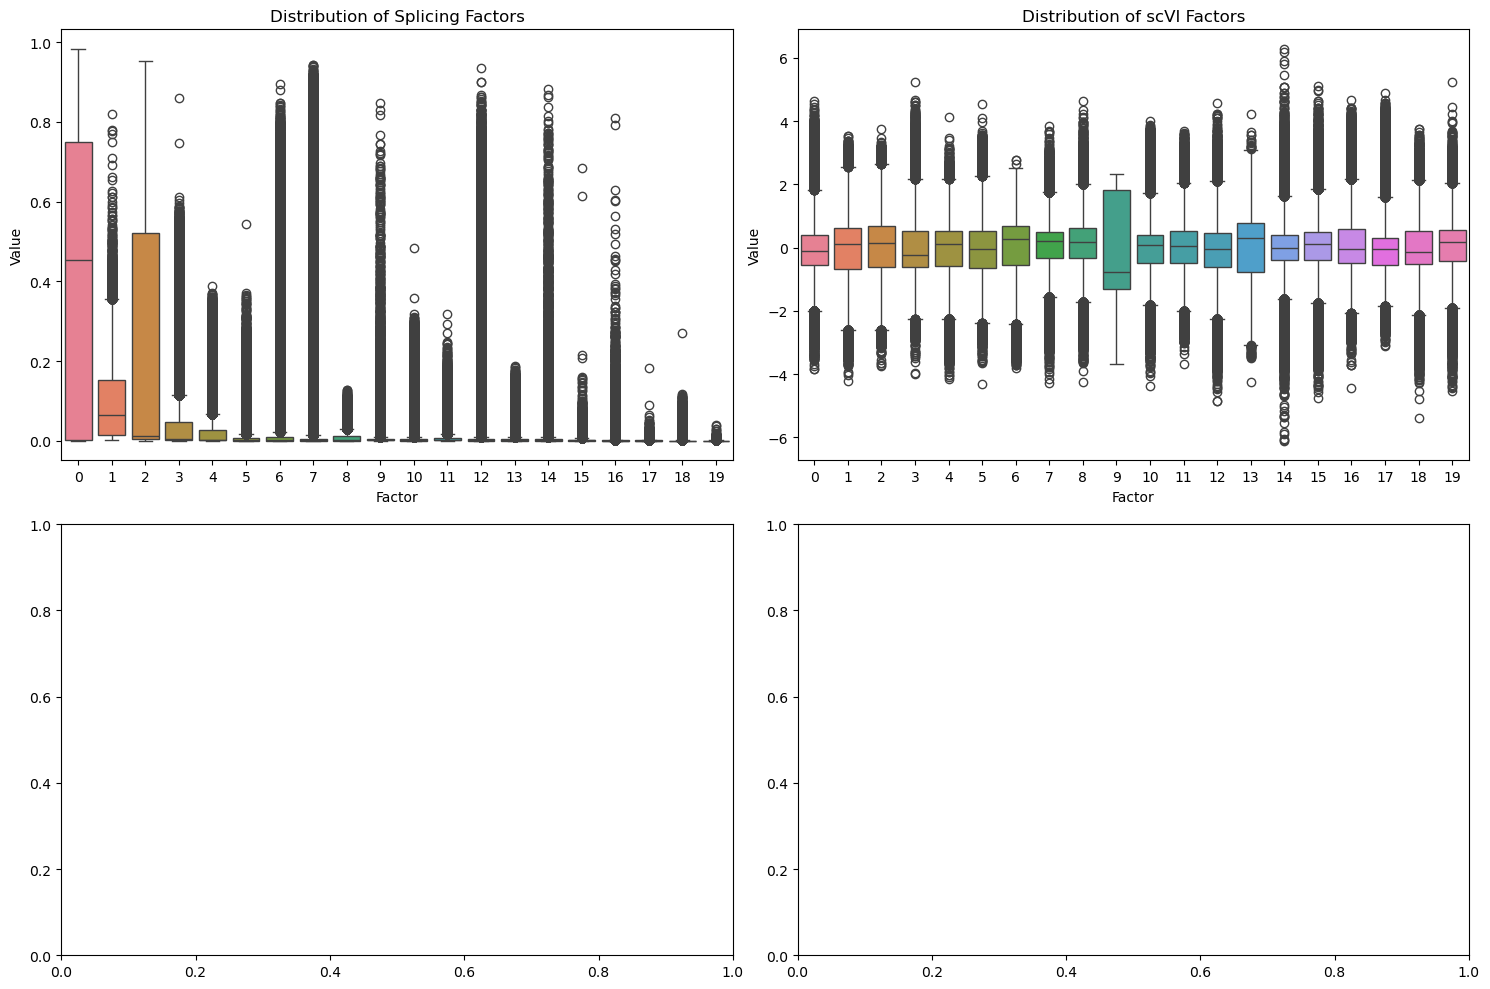

In [7]:
def create_age_celltype_heatmap(splice_adata, output_dir):
    """Create heatmap of cell counts by age and cell type."""
    print("Creating age vs cell type heatmap...")
    
    heatmap_data = pd.crosstab(
        splice_adata.obs['medium_cell_type'], 
        splice_adata.obs['age_numeric']
    ).fillna(0)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='g', 
                cmap='Blues',
                cbar_kws={'label': 'Cell Count'})
    plt.title('Cell Counts by Age and Medium Cell Type')
    plt.xlabel('Age (months)')
    plt.ylabel('Medium Cell Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig(f"{output_dir}/age_vs_celltype_heatmap.pdf", bbox_inches='tight')
    plt.show()

def create_factor_boxplots(splice_adata, ge_adata, output_dir):
    """Create boxplots for different factor types."""
    features = {
        'Splicing Factors': splice_adata.obsm["X_PHI"],
        'scVI Factors': ge_adata.obsm["X_scVI_linear"],
       # 'NMF Factors': ge_adata.obsm["X_nmf_standard_mb"],
       # 'PCA Factors': ge_adata.obsm["X_pca"]
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (name, data) in enumerate(features.items()):
        sns.boxplot(data=data, ax=axes[i])
        axes[i].set_title(f'Distribution of {name}')
        axes[i].set_xlabel('Factor')
        axes[i].set_ylabel('Value')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/factor_distributions.pdf", bbox_inches='tight')
    plt.show()

# Run EDA
create_age_celltype_heatmap(splice_adata, paths['output_dir'])
create_factor_boxplots(splice_adata, ge_adata, paths['output_dir'])

## 8. GSEA Pathway Analysis

In [8]:
gsea_data["scvi"]["full"].head()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,Database,Factor,Method,Database_key
0,prerank,Myelination (GO:0042552),0.612882,2.335805,0.000000,0.051504,0.02,9/14,12.05%,SOX10;LGI4;KLK6;PLP1;PMP22;GAL3ST1;ACSBG1;MPZ;...,GO Biological Process (2023),Z_1,scVI,GO_Biological_Process_2023
1,prerank,Post-Transcriptional Regulation Of Gene Expres...,0.507299,2.263197,0.000000,0.038628,0.03,16/16,49.60%,CYFIP1;RC3H1;GEMIN5;CELF1;ATXN2;MATR3;LARP1;MT...,GO Biological Process (2023),Z_1,scVI,GO_Biological_Process_2023
2,prerank,Microglial Cell Activation (GO:0001774),0.582020,1.976776,0.090909,0.103007,0.10,10/14,13.90%,CX3CR1;ITGAM;TREM2;C1QA;AIF1;MAPT;APP;GRN;ITGB...,GO Biological Process (2023),Z_1,scVI,GO_Biological_Process_2023
3,prerank,Synapse Organization (GO:0050808),0.529287,1.910054,0.000000,0.128759,0.15,8/16,10.15%,C1QC;C1QB;CX3CR1;C1QA;SLC6A1;MAPT;APP;CYFIP1,GO Biological Process (2023),Z_1,scVI,GO_Biological_Process_2023
4,prerank,Regulation Of Telomere Maintenance Via Telomer...,0.484015,1.831303,0.000000,0.195714,0.29,11/11,51.81%,PRKCQ;CTNNB1;PARN;XRCC5;MAPK1;TNKS2;XRN1;HNRNP...,GO Biological Process (2023),Z_1,scVI,GO_Biological_Process_2023


In [9]:
def summarize_top_gene_sets(df: pd.DataFrame,
                            q_cutoff: float = 0.05,
                            top_n: int = 5,
                            positive_only: bool = True) -> pd.DataFrame:
    """
    Return a tidy summary of the top `top_n` enriched gene sets
    (lowest FDR q-value, highest NES) for each factor.

    Parameters
    ----------
    df : pd.DataFrame
        GSEA results (one row per gene set) with at least the columns
        'Factor', 'Term', 'NES', and 'FDR q-val'.
    q_cutoff : float, default 0.05
        Maximum FDR q-value to keep.
    top_n : int, default 5
        How many gene sets to retain per factor.
    positive_only : bool, default True
        If True, keep only rows with NES > 0 (i.e. positively enriched).

    Returns
    -------
    pd.DataFrame
        Wide table whose index is Factor and whose columns
        list the top gene-set names, NES, and q-values.
    """
    # 1. basic filtering
    keep = df['FDR q-val'] < q_cutoff
    if positive_only:
        keep &= df['NES'] > 0
    filt = df.loc[keep].copy()

    # 2. sort within each factor (smallest q, then largest NES)
    filt.sort_values(['Factor', 'FDR q-val', 'NES'],
                     ascending=[True, True, False],
                     inplace=True)

    # 3. take top_n rows per factor
    top = filt.groupby('Factor').head(top_n)

    # 4. reshape for a quick at-a-glance table
    top['Rank'] = top.groupby('Factor').cumcount() + 1
    wide = (
        top
        .pivot_table(index='Factor',
                     columns='Rank',
                     values=['Term', 'NES', 'FDR q-val'],
                     aggfunc='first')
        .sort_index(axis=1, level=1)
    )

    # nice column order: Term1, NES1, q1, Term2, ...
    wide.columns = [f'{metric}{rank}'
                    for metric, rank in wide.columns]

    return wide


# gsea_data["scvi"]["full"] → DataFrame shown in your message
summary = summarize_top_gene_sets(gsea_data["scvi"]["full"],
                                  q_cutoff=0.05,
                                  top_n=3)

# Peek
summary

,FDR q-val1,NES1,Term1,FDR q-val2,NES2,Term2,FDR q-val3,NES3,Term3
Factor,,,,,,,,,
Z_1,0.0,3.479623,Oligodendrocyte Brain Non-Microglia CL:0000128,0.0,1.816052,Dendritic Cell Lung CL:0000451,0.00000,1.723715,Macrophage Lung CL:0000235
Z_10,0.0,3.169510,Neuron Projection (GO:0043005),0.0,3.100990,Neuron Brain Non-Microglia CL:0000540,0.00000,2.944985,Chemical Synaptic Transmission (GO:0007268)
Z_11,0.0,3.565784,Bladder Cell Bladder CL:1001319,0.0,3.117872,Epidermal Cell Skin CL:0000362,0.00000,3.031836,Keratinization R-HSA-6805567
Z_12,0.0,3.913798,Fibroblast Heart CL:0000057,0.0,3.898864,Mesenchymal Stem Cell Muscle CL:0000134,0.00000,3.858729,Mesenchymal Stem Cell Of Adipose Fat CL:0002570
Z_13,0.0,2.179142,Anterograde Trans-Synaptic Signaling (GO:0098916),0.0,1.943111,Intermediate Filament (GO:0005882),0.00738,1.850750,Stromal Cell Mammary CL:0000499
Z_14,0.0,3.802356,Endothelial Cell Trachea CL:0000115,0.0,3.575907,Endothelial Cell Muscle CL:0000115,0.00000,3.532761,Endothelial Cell Heart CL:0000115
Z_15,0.0,6.178679,Oligodendrocyte Brain Non-Microglia CL:0000128,0.0,2.478763,Stromal Cell Mammary CL:0000499,0.00000,2.471211,Mesenchymal Stem Cell Muscle CL:0000134
Z_16,0.0,2.143944,T Cell Lung CL:0000084,0.0,2.117717,T Cell Muscle CL:0000084,0.00000,2.093707,Pancreatic Acinar Cell Pancreas CL:0002064
Z_17,0.0,3.577008,Stromal Cell Lung CL:0000499,0.0,3.378251,Mesenchymal Stem Cell Of Adipose Fat CL:0002570,0.00000,3.134725,Pancreatic Stellate Cell Pancreas CL:0002410


## 9. Ridge Regression Analysis

In [10]:
splice_adata.obs["age_numeric"].value_counts()

age_numeric
2     49308
3     33730
24    27461
18    27394
Name: count, dtype: int64

In [11]:
def run_tissue_ridge_analysis(splice_adata, ge_adata, covariate="medium_cell_type", 
                             alphas=np.logspace(-2, 3, 20)):
    """
    Run ridge regression analysis by tissue/cell type.
    """
    print(f"Running ridge regression analysis by {covariate}...")
    
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    for tissue in tqdm(splice_adata.obs[covariate].unique()):
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
            
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        # Get R² scores
        r2_sp = ridge_sp.score(X_sp, y)
        r2_sc = ridge_sc.score(X_sc, y)
        r2_comb = ridge_comb.score(X_comb, y)
        
        # Statistical tests
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        # F-tests
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
        
        # Feature importance
        combined_coefs = ridge_comb.coef_
        splice_coefs = combined_coefs[:n_splice_factors]
        scvi_coefs = combined_coefs[n_splice_factors:]
        
        for i, coef in enumerate(splice_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
        
        for i, coef in enumerate(scvi_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
    
    return results, pd.DataFrame(feature_importance_data)

from scipy import stats
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

def bootstrap_ridge_coefficients(X, y, alphas=np.logspace(-2, 3, 20), n_bootstrap=100):
    """
    Bootstrap Ridge regression to get coefficient confidence intervals.
    """
    n_features = X.shape[1]
    bootstrap_coefs = []
    
    # Fit original model to get best alpha
    ridge = RidgeCV(alphas=alphas, cv=5).fit(X, y)
    best_alpha = ridge.alpha_
    
    # Bootstrap sampling
    for i in range(n_bootstrap):
        # Resample with replacement
        X_boot, y_boot = resample(X, y, random_state=i)
        
        # Fit ridge with best alpha
        ridge_boot = RidgeCV(alphas=[best_alpha], cv=3).fit(X_boot, y_boot)
        bootstrap_coefs.append(ridge_boot.coef_)
    
    bootstrap_coefs = np.array(bootstrap_coefs)
    
    # Calculate confidence intervals (2.5% and 97.5% percentiles)
    ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
    
    return ridge.coef_, ci_lower, ci_upper, ridge.score(X, y)


def run_tissue_ridge_analysis_with_ci(splice_adata, ge_adata, covariate="medium_cell_type",
                                     alphas=np.logspace(-2, 3, 20), n_bootstrap=50):
    """
    Enhanced ridge regression analysis with confidence intervals.
    """
    print(f"Running ridge regression analysis with CI by {covariate}...")
    
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    for tissue in splice_adata.obs[covariate].unique():
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
        
        print(f"  Processing {tissue} ({mask.sum()} cells)...")
        
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models with confidence intervals
        sp_coef, sp_ci_low, sp_ci_high, r2_sp = bootstrap_ridge_coefficients(X_sp, y, alphas, n_bootstrap)
        sc_coef, sc_ci_low, sc_ci_high, r2_sc = bootstrap_ridge_coefficients(X_sc, y, alphas, n_bootstrap)
        comb_coef, comb_ci_low, comb_ci_high, r2_comb = bootstrap_ridge_coefficients(X_comb, y, alphas, n_bootstrap)
        
        # Statistical tests (same as before)
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
        
        # Store coefficients with confidence intervals
        # Combined model coefficients
        splice_coefs_comb = comb_coef[:n_splice_factors]
        scvi_coefs_comb = comb_coef[n_splice_factors:]
        splice_ci_low_comb = comb_ci_low[:n_splice_factors]
        splice_ci_high_comb = comb_ci_high[:n_splice_factors]
        scvi_ci_low_comb = comb_ci_low[n_splice_factors:]
        scvi_ci_high_comb = comb_ci_high[n_splice_factors:]
        
        for i, (coef, ci_low, ci_high) in enumerate(zip(splice_coefs_comb, splice_ci_low_comb, splice_ci_high_comb)):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'ci_lower': ci_low,
                'ci_upper': ci_high,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc,
                'significant': ci_low * ci_high > 0  # CI doesn't cross zero
            })
        
        for i, (coef, ci_low, ci_high) in enumerate(zip(scvi_coefs_comb, scvi_ci_low_comb, scvi_ci_high_comb)):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'ci_lower': ci_low,
                'ci_upper': ci_high,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc,
                'significant': ci_low * ci_high > 0
            })
    
    return results, pd.DataFrame(feature_importance_data)

In [12]:
assert all(splice_adata.obs_names == ge_adata.obs_names)
ge_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]

In [13]:
# remove 2months old cells from splice_adata.obs["age_numeric"]
splicing_aging = splice_adata[splice_adata.obs["age_numeric"] != 2].copy()
ge_adata_aging = ge_adata[ge_adata.obs["age_numeric"] != 2].copy()
assert all(splicing_aging.obs_names == ge_adata_aging.obs_names)

In [14]:
# Run ridge regression analysis
results, feature_importance_df = run_tissue_ridge_analysis(splicing_aging, ge_adata_aging)

Running ridge regression analysis by medium_cell_type...


100%|██████████| 53/53 [00:38<00:00,  1.38it/s]


In [15]:
# Run analysis with confidence intervals
results_ci, feature_df_ci = run_tissue_ridge_analysis_with_ci(splicing_aging, ge_adata_aging, n_bootstrap=50)

Running ridge regression analysis with CI by medium_cell_type...
  Processing Respiratory epithelial cell (323 cells)...
  Processing Skin epithelial cell (7343 cells)...
  Processing Other immune cell (2575 cells)...
  Processing Endothelial cell (7065 cells)...
  Processing Cardiomyocyte (438 cells)...
  Processing Smooth muscle cell (2056 cells)...
  Processing Intestinal epithelial cell (2940 cells)...
  Processing Epithelial stem cell (912 cells)...
  Processing Fibroblast (4623 cells)...
  Processing Secretory cell (281 cells)...
  Processing B cell (8640 cells)...
  Processing Granulocyte (2864 cells)...
  Processing T cell (3588 cells)...
  Processing Immune progenitor (1210 cells)...
  Processing Cardiac stromal cell (576 cells)...
  Processing Urogenital epithelial cell (1014 cells)...
  Processing Pancreatic endocrine cell (1454 cells)...
  Processing Nk cell (716 cells)...
  Processing Microglia (12060 cells)...
  Processing T cell precursor (3012 cells)...
  Processing Kid

## 10. Results Visualization

In [16]:
def create_performance_plot(results, output_dir):
    """Create performance comparison plot."""
    # Create summary DataFrame
    summary_data = []
    for tissue, res in results.items():
        summary_data.append({
            'tissue': tissue,
            'n_cells': res['n_cells'],
            'LeafletFA_r2': res['splice_r2'],
            'scVI_r2': res['scvi_r2'],
            'LeafletFA_scVI_r2': res['combined_r2'],
            'p_combined_vs_LeafletFA': res['p_combined_vs_splice'],
            'p_combined_vs_scVI': res['p_combined_vs_scvi']
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # FDR correction
    summary_df["p_combined_vs_scVI_fdr"] = multipletests(
        summary_df["p_combined_vs_scVI"], method="fdr_bh"
    )[1]
    
    # Sort and reshape for plotting
    summary_df_sorted = summary_df.sort_values('LeafletFA_r2', ascending=False)
    
    plot_data = []
    for _, row in summary_df_sorted.iterrows():
        for model in ['LeafletFA', 'scVI', 'LeafletFA_scVI']:
            plot_data.append({
                'tissue': row['tissue'],
                'model': model,
                'r2': row[f'{model}_r2']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    sns.barplot(data=plot_df, x='tissue', y='r2', hue='model', ax=ax, alpha=0.8)
    
    # Add significance markers
    for i, (_, row) in enumerate(summary_df_sorted.iterrows()):
        p_val = row['p_combined_vs_scVI_fdr']
        sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        if sig_text:
            combined_r2 = row['LeafletFA_scVI_r2']
            ax.text(i, combined_r2 + 0.02, sig_text, ha='center', va='bottom', 
                   fontweight='bold', fontsize=10)
    
    ax.set_xlabel('Cell Type', fontsize=14)
    ax.set_ylabel('Age Prediction Ridge Regression R²', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(f'{output_dir}/age_prediction_performance.pdf', dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_dir}/age_prediction_performance.pdf")
    plt.show()
    
    return summary_df

In [17]:
def create_correlation_analysis_with_gene_loadings(splice_adata, ge_adata, output_dir):
    """Create correlation analysis between scVI and LeafletFA factors with top gene loadings."""
    print("Computing factor correlations with gene loading annotations...")
    
    X_PHI = splice_adata.obsm["X_PHI"]
    X_scVI = ge_adata.obsm["X_scVI_linear"]
    scvi_gene_loadings = ge_adata.varm["scVI_linear_gene_loadings"]
    gene_names = ge_adata.var["gene_name"].values
    
    n_scvi_factors = X_scVI.shape[1]
    n_splicing_factors = X_PHI.shape[1]
    
    # Compute correlations
    corr_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
    pval_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
    
    for i in range(n_scvi_factors):
        for j in range(n_splicing_factors):
            rho, pval = spearmanr(X_scVI[:, i], X_PHI[:, j])
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval
    
    # FDR correction
    _, pvals_fdr_flat, _, _ = multipletests(pval_matrix.flatten(), method='fdr_bh')
    fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)
    
    # Create significance annotations
    fdr_thresh = 0.05
    rho_thresh = 0.2
    annot_matrix = np.where(
        (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh),
        "*", ""
    )
    
    # Create scVI factor labels with top 5 genes
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    scvi_labels_with_genes = []
    gene_loading_summary = []
    
    for i, factor_name in enumerate(scvi_factor_names):
        # Get top 5 genes by absolute loading values
        factor_loadings = scvi_gene_loadings.iloc[:, i].values
        top_gene_indices = np.argsort(-np.abs(factor_loadings))[:5]  # Top 5 genes
        top_genes = gene_names[top_gene_indices]
        top_loadings = factor_loadings[top_gene_indices]
        
        # Create label with top 3 genes for display (to keep labels readable)
        gene_label = f"{factor_name}: {', '.join(top_genes[:5])}"
        scvi_labels_with_genes.append(gene_label)
        
        # Store detailed info for all top 5 genes
        gene_loading_summary.append({
            'Factor': factor_name,
            'Top_Gene_1': top_genes[0],
            'Loading_1': top_loadings[0],
            'Top_Gene_2': top_genes[1],
            'Loading_2': top_loadings[1],
            'Top_Gene_3': top_genes[2],
            'Loading_3': top_loadings[2],
            'Top_Gene_4': top_genes[3],
            'Loading_4': top_loadings[3],
            'Top_Gene_5': top_genes[4],
            'Loading_5': top_loadings[4],
            'Top_3_Display': ', '.join(top_genes[:3]),
            'Top_5_All': ', '.join(top_genes)
        })
    
    splicing_factor_names = [f"SP_{i+1}" for i in range(n_splicing_factors)]
    
    # Create correlation DataFrame
    corr_df = pd.DataFrame(
        corr_matrix,
        index=scvi_labels_with_genes,
        columns=splicing_factor_names
    )
    
    # Create clustermap with PRGn colormap
    plt.figure(figsize=(8,6))  # Increased size for gene labels
    
    g = sns.clustermap(
        corr_df,
        cmap="PRGn",
        center=0,
        linewidths=0.3,
        linecolor="white",
        xticklabels=True,
        yticklabels=True,
        annot=annot_matrix,
        fmt='',
        annot_kws={'size': 8, 'color': 'black', 'weight': 'bold'},
        figsize=(8,6),
        cbar_kws={'label': 'Spearman Correlation', 'shrink': 0.8},
        col_cluster=False,  # Don't cluster columns (keep SP order)
        row_cluster=True   # Cluster rows (scVI factors)
    )
    
    g.ax_heatmap.set_xlabel("LeafletFA Splicing Programs", fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel("scVI Latent Factors (Top Genes)", fontsize=14, fontweight='bold')
    
    # Adjust label formatting
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
    
    # Add significance legend
    legend_text = f"* Significant: FDR < {fdr_thresh}, |ρ| > {rho_thresh}"
    g.fig.text(0.02, 0.98, legend_text, fontsize=11, style='italic',
               verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", 
               facecolor="lightgray", alpha=0.7))
    
    # Save the plot
    output_path = f"{output_dir}/scVI_leafletFA_correlation_with_gene_loadings.pdf"
    g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Save correlation matrix with gene annotations
    corr_df.to_csv(f"{output_dir}/scVI_leafletFA_correlations_with_gene_loadings.csv")
    
    # Save detailed gene loading summary
    gene_loading_df = pd.DataFrame(gene_loading_summary)
    gene_loading_df.to_csv(f"{output_dir}/scVI_top5_gene_loadings_summary.csv", index=False)
    
    print(f"Saved correlation analysis with gene loadings to: {output_path}")
    print(f"Saved detailed gene loading summary to: {output_dir}/scVI_top5_gene_loadings_summary.csv")
    
    # Print summary of top genes
    print("\nTop 5 gene loadings for each scVI factor:")
    for i, summary in enumerate(gene_loading_summary):
        print(f"  {summary['Factor']}: {summary['Top_5_All']}")
        if i >= 9:  # Show first 10 factors
            remaining = len(gene_loading_summary) - 10
            if remaining > 0:
                print(f"  ... and {remaining} more factors (see CSV for complete list)")
            break
    
    return corr_df, gene_loading_df

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/age_prediction_performance.pdf


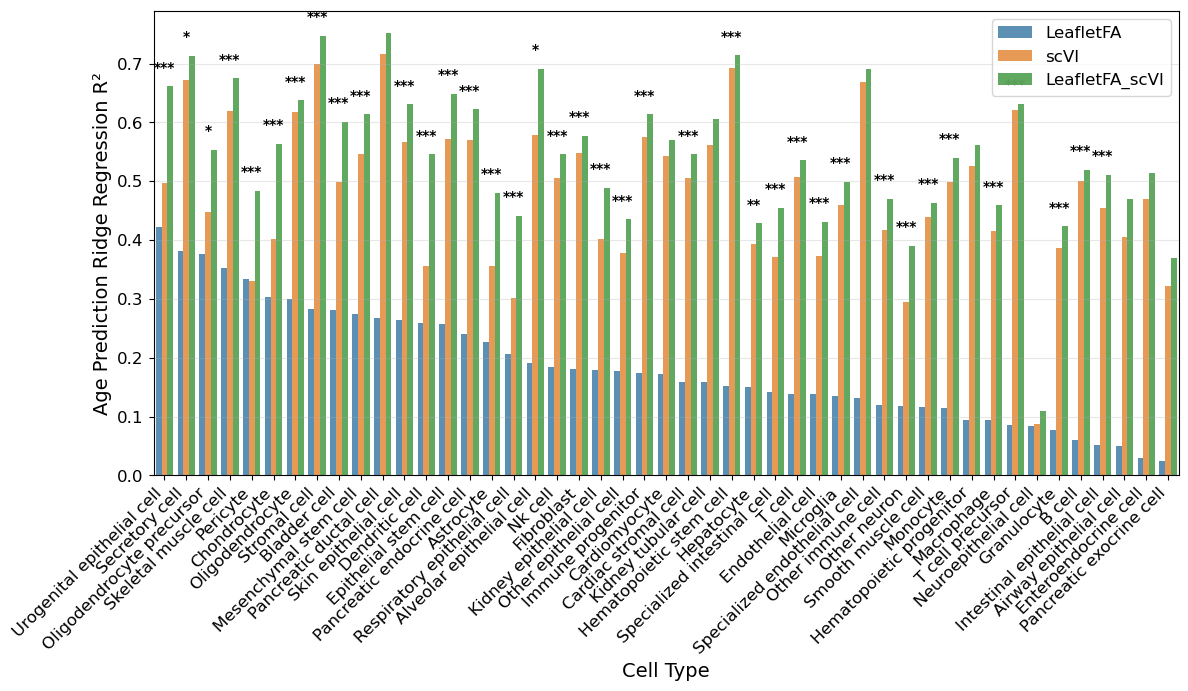

In [18]:
# Run visualizations
summary_df = create_performance_plot(results, paths['output_dir'])

In [19]:
#sc.pl.umap(ge_adata, color=[SCVI_CLUSTERS_KEY])
#zs = [f"Z_{i}" for i in 20]
#sc.pl.umap(ge_adata, color=zs, ncols=3)

In [20]:
ge_adata_aging, splicing_aging

(AnnData object with n_obs × n_vars = 88585 × 2482
     obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', 'nuclear_score_log_norm', 'nuclear_ratio_log_norm', 'nuclear_rrna_log_norm', 'nuclear_class_log_norm', 'nuclear_score_predicted_log_norm_tms', 'nuclear_ratio_predicted_log_norm_tms', 'nuclear_rrna_predicted_log_norm_tms', 'nuclear_class_predicted_log_norm_tms', 'AgingScore_pos', 'AgingScore_neg', 'AgingScore_unweighted', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'age_numeric'
     var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'transcript_biotypes', 'is_rRNA', 'n_cells_by_counts', 'mean_counts'

Computing factor correlations with gene loading annotations...


<Figure size 800x600 with 0 Axes>

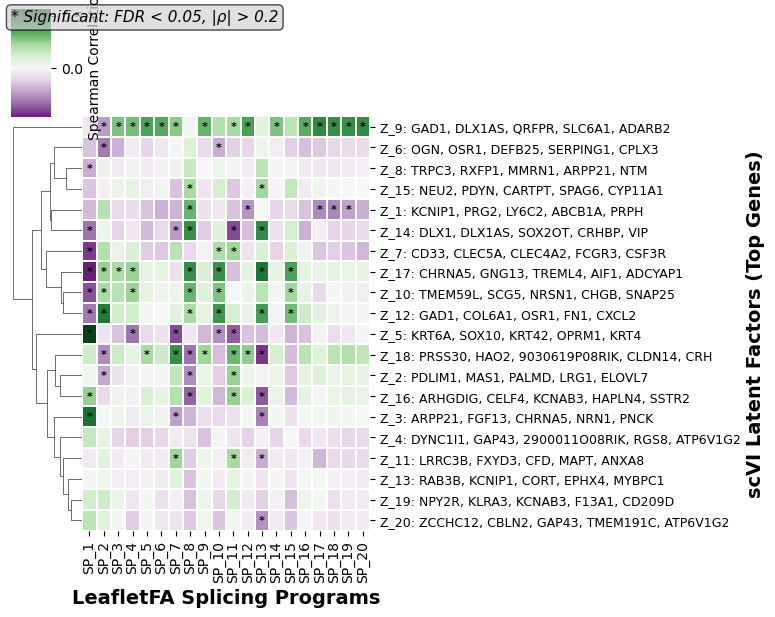

Saved correlation analysis with gene loadings to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/scVI_leafletFA_correlation_with_gene_loadings.pdf
Saved detailed gene loading summary to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/scVI_top5_gene_loadings_summary.csv

Top 5 gene loadings for each scVI factor:
  Z_1: KCNIP1, PRG2, LY6C2, ABCB1A, PRPH
  Z_2: PDLIM1, MAS1, PALMD, LRG1, ELOVL7
  Z_3: ARPP21, FGF13, CHRNA5, NRN1, PNCK
  Z_4: DYNC1I1, GAP43, 2900011O08RIK, RGS8, ATP6V1G2
  Z_5: KRT6A, SOX10, KRT42, OPRM1, KRT4
  Z_6: OGN, OSR1, DEFB25, SERPING1, CPLX3
  Z_7: CD33, CLEC5A, CLEC4A2, FCGR3, CSF3R
  Z_8: TRPC3, RXFP1, MMRN1, ARPP21, NTM
  Z_9: GAD1, DLX1AS, QRFPR, SLC6A1, ADARB2
  Z_10: TMEM59L, SCG5, NRSN1, CHGB, SNAP25
  ... and 10 more factors (see CSV for com

In [21]:
# Replace your correlation analysis call with:
corr_df, gene_loading_df = create_correlation_analysis_with_gene_loadings(
    splicing_aging, ge_adata_aging, paths['output_dir']
)

In [22]:
def create_ridge_coefficients_clustermap(feature_importance_df, splice_adata, output_dir):
    """Create clustermap of ridge coefficients by cell type and factor."""
    print("Creating ridge coefficients clustermap...")
    
    # Pivot the data to create coefficient matrix
    coef_matrix = feature_importance_df.pivot_table(
        index='cell_type',
        columns='factor_name', 
        values='coefficient',
        fill_value=0
    )
    
    # Create mapping from cell_type to broad_cell_type
    cell_type_mapping = splice_adata.obs[['medium_cell_type', 'broad_cell_type']].drop_duplicates()
    cell_type_mapping = cell_type_mapping.set_index('medium_cell_type')['broad_cell_type'].to_dict()
    
    # Get cell counts for each medium cell type
    cell_counts = splice_adata.obs['medium_cell_type'].value_counts().to_dict()
    
    # Create consistent color palette for broad cell types
    unique_broad = splice_adata.obs["broad_cell_type"].unique()
    palette = sns.color_palette("tab20", len(unique_broad))
    palette_dict = dict(zip(unique_broad, palette))
    
    # Create row colors based on broad_cell_type
    broad_cell_types = [cell_type_mapping.get(ct, 'Unknown') for ct in coef_matrix.index]
    row_colors = pd.Series([palette_dict.get(bct, (0.5, 0.5, 0.5)) for bct in broad_cell_types], 
                          index=coef_matrix.index, name='Broad Cell Type')
    
    # Update row labels to include cell counts
    new_row_labels = []
    for ct in coef_matrix.index:
        count = cell_counts.get(ct, 0)
        new_row_labels.append(f"{ct} ({count})")
    
    # Create a copy of the matrix with updated row labels
    coef_matrix_with_counts = coef_matrix.copy()
    coef_matrix_with_counts.index = new_row_labels
    
    # Update row_colors index to match
    row_colors.index = new_row_labels
    
    # Get factor names and separate SP and Z factors
    all_factors = coef_matrix_with_counts.columns.tolist()
    sp_factors = sorted([f for f in all_factors if f.startswith('SP_')], 
                       key=lambda x: int(x.split('_')[1]))
    z_factors = sorted([f for f in all_factors if f.startswith('Z_')], 
                      key=lambda x: int(x.split('_')[1]))
    
    # Create ordered factor list: SP_1, SP_2, ..., Z_1, Z_2, ...
    ordered_factors = sp_factors + z_factors
    
    # Reorder columns according to our desired order
    coef_matrix_ordered = coef_matrix_with_counts[ordered_factors]
    
    # Create figure
    plt.figure(figsize=(16, 10))
    
    # Create clustermap
    g = sns.clustermap(
        coef_matrix_ordered,
        cmap="PRGn",
        center=0,
        linewidths=0.5,
        linecolor="white",
        xticklabels=True,
        yticklabels=True,
        figsize=(18, 12),  # Increased width for color bar
        cbar_kws={'label': 'Ridge Coefficient', 'shrink': 0.8},
        col_cluster=False,  # Don't cluster columns (keep factor order)
        row_cluster=True,   # Cluster rows (cell types)
        row_colors=row_colors,  # Add broad cell type colors
        dendrogram_ratio=0.1,  # Make dendrograms smaller
        colors_ratio=0.03  # Width of the color bar
    )
    
    # Customize the plot
    g.ax_heatmap.set_xlabel("Factors (SP: Splicing Programs, Z: scVI Latent Factors)", 
                           fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel("Cell Types", fontsize=14, fontweight='bold')
    
    # Rotate and adjust tick labels
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)
    
    # Add vertical line to separate SP and Z factors
    n_sp_factors = len(sp_factors)
    g.ax_heatmap.axvline(x=n_sp_factors-0.5, color='black', linewidth=2, alpha=0.8)
    
    # Add text annotations to distinguish factor types
    g.ax_heatmap.text(n_sp_factors/2 - 0.5, -1.5, 'Splicing Programs', 
                     ha='center', va='top', fontsize=12, fontweight='bold')
    g.ax_heatmap.text(n_sp_factors + len(z_factors)/2 - 0.5, -1.5, 'Gene Expression', 
                     ha='center', va='top', fontsize=12, fontweight='bold')
    
    # Create custom legend for broad cell types (only show types that appear in the clustermap)
    from matplotlib.patches import Patch
    broad_types_in_plot = list(set(broad_cell_types))
    legend_elements = [Patch(facecolor=palette_dict.get(bct, (0.5, 0.5, 0.5)), label=bct) 
                      for bct in sorted(broad_types_in_plot)]
    
    # Add legend for broad cell types
    g.ax_heatmap.legend(handles=legend_elements, 
                       title='Broad Cell Type',
                       bbox_to_anchor=(1.05, 1), 
                       loc='upper left',
                       frameon=True,
                       fancybox=True,
                       shadow=True)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save the plot
    output_path = f"{output_dir}/ridge_coefficients_clustermap.pdf"
    g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Save the coefficient matrix
    coef_matrix_ordered.to_csv(f"{output_dir}/ridge_coefficients_matrix.csv")
    
    # Save additional info about broad cell types
    broad_cell_type_info = pd.DataFrame({
        'medium_cell_type': coef_matrix.index,  # Original names without counts
        'medium_cell_type_with_counts': new_row_labels,
        'broad_cell_type': broad_cell_types,
        'cell_count': [cell_counts.get(ct, 0) for ct in coef_matrix.index],
        'color': [palette_dict.get(bct, (0.5, 0.5, 0.5)) for bct in broad_cell_types]
    })
    broad_cell_type_info.to_csv(f"{output_dir}/broad_cell_type_colors.csv", index=False)
    
    print(f"Saved ridge coefficients clustermap to: {output_path}")
    print(f"Saved coefficient matrix to: {output_dir}/ridge_coefficients_matrix.csv")
    print(f"Saved broad cell type colors to: {output_dir}/broad_cell_type_colors.csv")
    
    # Print summary statistics
    print(f"\nClustermap Summary:")
    print(f"  Cell types: {len(coef_matrix_ordered.index)}")
    print(f"  Broad cell types in plot: {len(set(broad_cell_types))}")
    print(f"  Total broad cell types available: {len(unique_broad)}")
    print(f"  Splicing factors (SP): {len(sp_factors)}")
    print(f"  Gene expression factors (Z): {len(z_factors)}")
    print(f"  Total factors: {len(ordered_factors)}")
    print(f"  Coefficient range: {coef_matrix_ordered.min().min():.3f} to {coef_matrix_ordered.max().max():.3f}")
    
    # Print broad cell type distribution
    print(f"\nBroad cell type distribution in clustermap:")
    broad_type_counts = pd.Series(broad_cell_types).value_counts()
    for bct, count in broad_type_counts.items():
        total_cells = sum([cell_counts.get(ct, 0) for ct, bct_mapped in cell_type_mapping.items() if bct_mapped == bct and ct in coef_matrix.index])
        print(f"  {bct}: {count} medium cell types, {total_cells} total cells")
    
    # Show top positive and negative coefficients
    coef_flat = coef_matrix_ordered.stack().reset_index()
    coef_flat.columns = ['cell_type', 'factor', 'coefficient']
    
    print(f"\nTop 5 positive coefficients:")
    top_pos = coef_flat.nlargest(5, 'coefficient')
    for _, row in top_pos.iterrows():
        print(f"  {row['cell_type']} - {row['factor']}: {row['coefficient']:.3f}")
    
    print(f"\nTop 5 negative coefficients:")
    top_neg = coef_flat.nsmallest(5, 'coefficient')
    for _, row in top_neg.iterrows():
        print(f"  {row['cell_type']} - {row['factor']}: {row['coefficient']:.3f}")
    
    return coef_matrix_ordered, g

Creating ridge coefficients clustermap...


<Figure size 1600x1000 with 0 Axes>

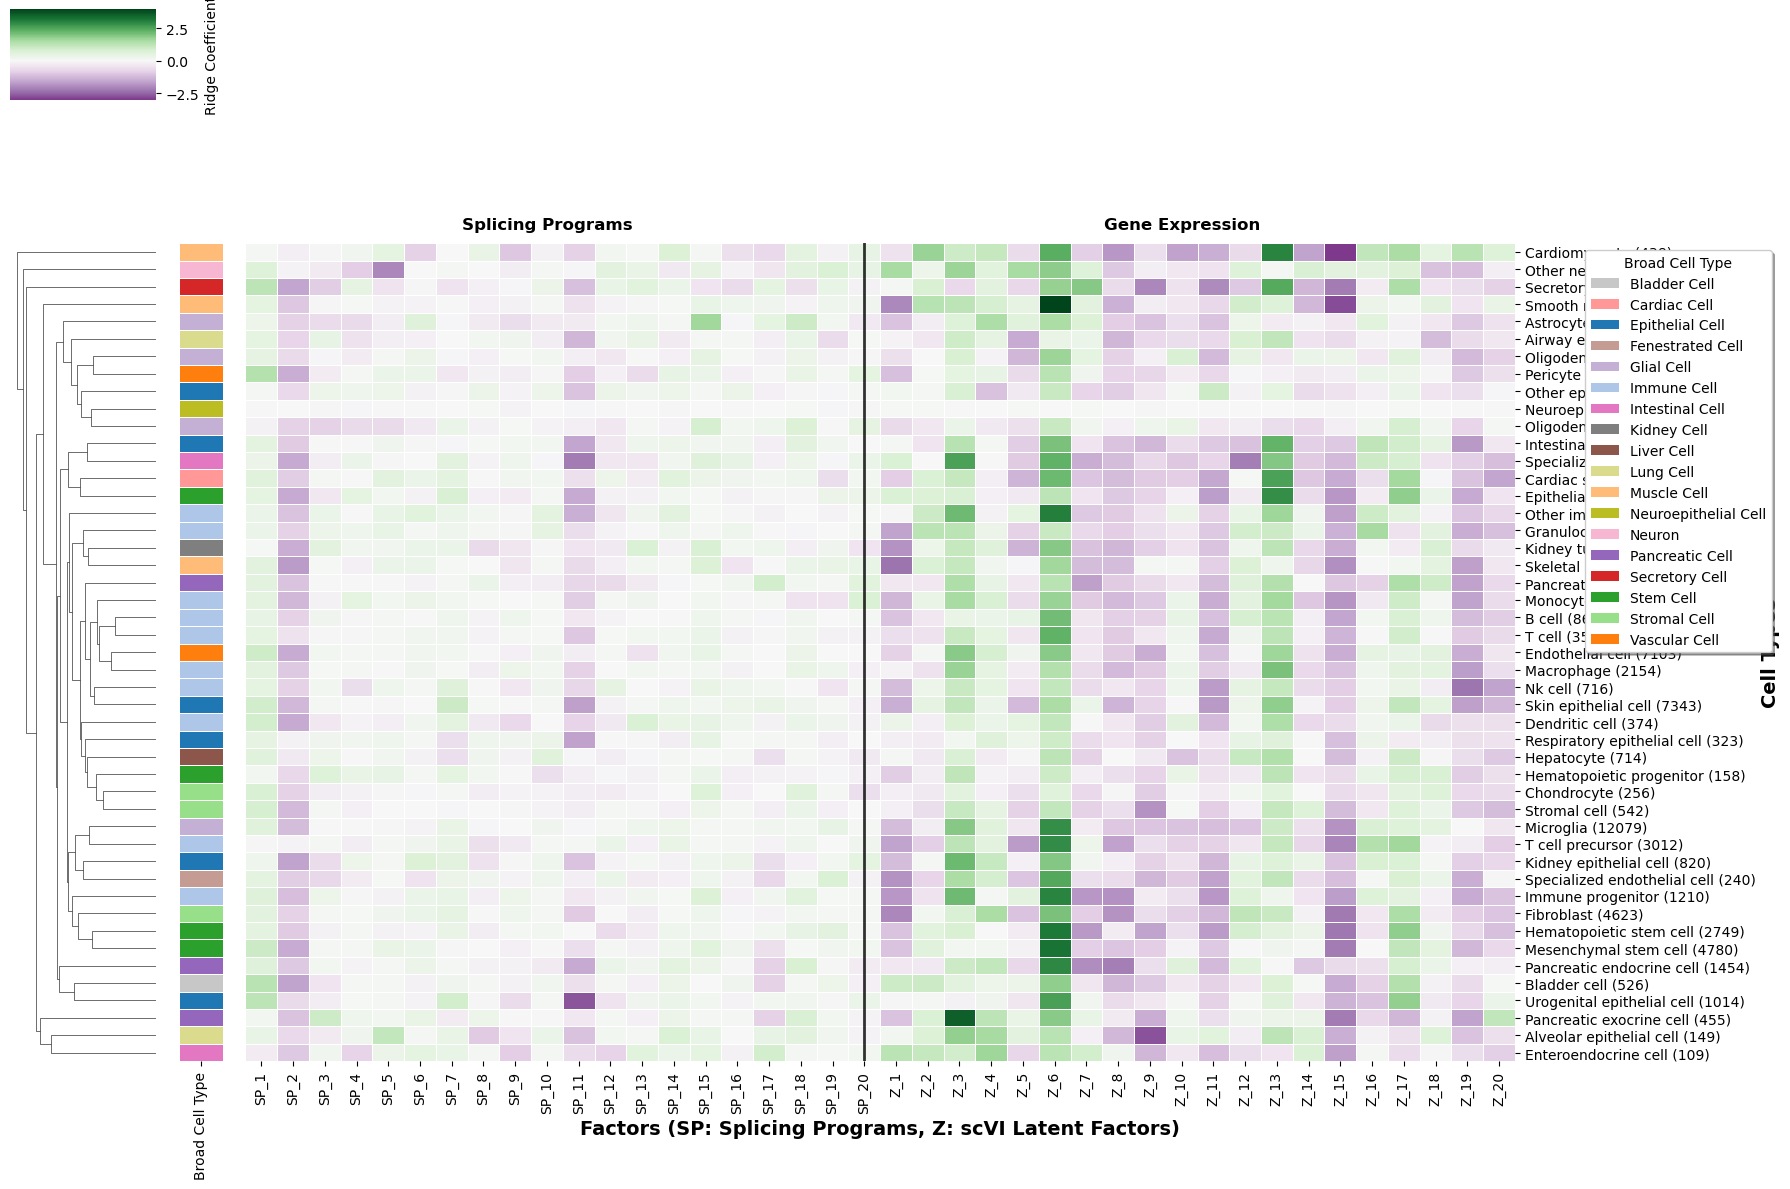

Saved ridge coefficients clustermap to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/ridge_coefficients_clustermap.pdf
Saved coefficient matrix to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/ridge_coefficients_matrix.csv
Saved broad cell type colors to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/broad_cell_type_colors.csv

Clustermap Summary:
  Cell types: 47
  Broad cell types in plot: 18
  Total broad cell types available: 19
  Splicing factors (SP): 20
  Gene expression factors (Z): 20
  Total factors: 40
  Coefficient range: -3.002 to 3.982

Broad cell type distribution in clustermap:
  Immune Cell: 10 medium cell types, 26428 total cells
  Epithelial

In [23]:
coef_matrix, clustermap_obj = create_ridge_coefficients_clustermap(
    feature_importance_df, splice_adata, paths['output_dir']
)

In [24]:
# rename columns ge_adata.varm["scVI_linear_gene_loadings"] to be Z_1 to Z_20 
ge_adata.varm["scVI_linear_gene_loadings"].columns = [f"Z_{i}" for i in range(1, 21)]
print(ge_adata.varm["scVI_linear_gene_loadings"].head())

                Z_1       Z_2       Z_3       Z_4       Z_5       Z_6  \
gene_name                                                               
LDLRAD1    0.134699  0.379205 -0.351969 -0.330493 -0.395734 -0.609852   
VNN1      -0.422193  0.066645 -0.400018 -0.032650 -0.450940 -1.434670   
RPSA      -0.515294  0.256668  0.374679  0.061833 -0.025462 -0.184939   
CYP4A31    0.115770 -0.559618 -0.343643  0.153004 -0.259944 -0.551258   
DMBT1     -0.961315 -0.195295 -1.124600 -0.523794 -0.580569 -0.207013   

                Z_7       Z_8       Z_9      Z_10      Z_11      Z_12  \
gene_name                                                               
LDLRAD1   -0.303116 -0.037476  0.494103  0.653703 -0.596550 -0.355818   
VNN1       0.475661  0.348910 -0.320366 -0.960197  0.068499  0.499496   
RPSA       0.266351 -0.491213 -0.216130 -0.852381 -0.177420 -0.452177   
CYP4A31   -0.443446  0.066310  0.403094 -0.490898 -0.276255 -0.634342   
DMBT1      0.355417  0.278349  1.302615 -1.401921 

##  Visualize Factor Activity in a Given Cell Type

In [25]:
def plot_factor_activity_by_age(
    adata,
    factor_matrix_key,
    factor_prefix,
    factor_index,
    cell_type_name,
    obs_col="medium_cell_type",
    age_col="age_numeric"
):
    """
    Plot a specific factor's activity across ages within a selected cell type.
    Adds cell counts to x-axis labels and adjusts color if factor is gene expression.
    """
    # Filter to the target cell type
    mask = adata.obs[obs_col] == cell_type_name
    if mask.sum() == 0:
        print(f"No cells found for cell type: {cell_type_name}")
        return

    # Get data
    factor_values = adata.obsm[factor_matrix_key][mask, factor_index]
    ages = adata.obs.loc[mask, age_col]

    # Build DataFrame
    factor_label = f"{factor_prefix}_{factor_index + 1}"
    df = pd.DataFrame({
        factor_label: factor_values,
        "age": ages
    })

    # Compute counts and relabel x-axis
    age_counts = df["age"].value_counts().sort_index()
    age_labels = [f"{int(age)} (n={count})" for age, count in age_counts.items()]
    age_order = age_counts.index.tolist()

    # Choose color palette
    if factor_prefix.upper().startswith("Z"):
        violin_color = "#4C72B0"  # blue for gene expression
    else:
        violin_color = "#55A868"  # green for splicing

    # Plot
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=df, x="age", y=factor_label,
        order=age_order,
        inner="box", linewidth=1, color=violin_color
    )
    sns.stripplot(
        data=df, x="age", y=factor_label,
        order=age_order,
        color="black", alpha=0.3, jitter=0.2, size=2
    )

    # Set custom x-tick labels
    plt.xticks(ticks=range(len(age_labels)), labels=age_labels, rotation=0)
    plt.title(f"{factor_label} Activity in {cell_type_name} by Age", fontsize=13)
    plt.xlabel("Age (with cell counts)")
    plt.ylabel("Factor Activity")
    plt.tight_layout()
    plt.show()

In [26]:
splicing_aging, ge_adata_aging

(AnnData object with n_obs × n_vars = 88585 × 35197
     obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm'
     var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detecte

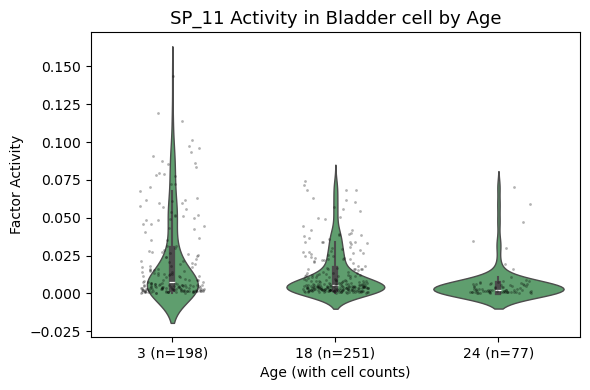

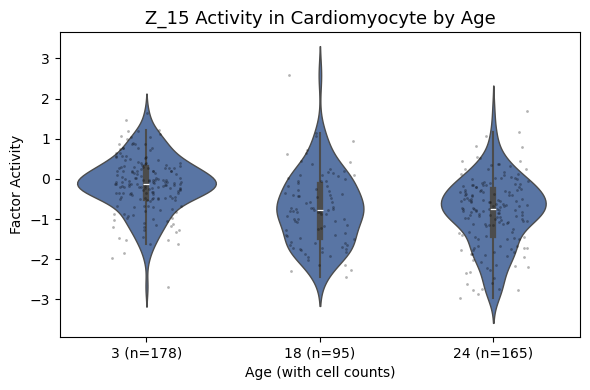

In [27]:
plot_factor_activity_by_age(splicing_aging, "X_PHI", "SP", factor_index=10, cell_type_name="Bladder cell")
plot_factor_activity_by_age(ge_adata_aging, "X_scVI_linear", "Z", factor_index=14, cell_type_name="Cardiomyocyte")

## Correlation Between SP and Z Factors in a Given Cell Type

In [28]:
def plot_sp_z_correlation(splice_adata, ge_adata, sp_index, z_index, cell_type_name, obs_col="medium_cell_type"):
    """
    Scatter plot of SP and Z factor activity for a specific cell type.
    """
    # Add option to plot all cells 
    # Make hexbin version to group points into high density regions
    mask = splice_adata.obs[obs_col] == cell_type_name
    sp_val = splice_adata.obsm["X_PHI"][mask, sp_index]
    z_val = ge_adata.obsm["X_scVI_linear"][mask, z_index]
    
    df = pd.DataFrame({
        f"SP_{sp_index+1}": sp_val,
        f"Z_{z_index+1}": z_val
    })

    corr = np.corrcoef(sp_val, z_val)[0, 1]
    
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=f"SP_{sp_index+1}", y=f"Z_{z_index+1}", data=df, s=20, alpha=0.7, edgecolor='black')
    plt.title(f"{cell_type_name}: SP_{sp_index+1} vs Z_{z_index+1}\nPearson r = {corr:.2f}")
    plt.tight_layout()
    plt.show()

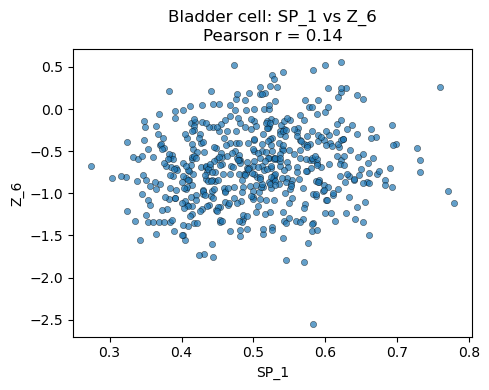

In [29]:
plot_sp_z_correlation(splice_adata, ge_adata, sp_index=0, z_index=5, cell_type_name="Bladder cell")

In [30]:
from scipy import stats

def create_factor_barplot_summary(feature_importance_df, output_dir):
    """
    Publication-ready bar plot showing mean coefficients with error bars
    and annotations for consistency.
    """
    print("🔍 Creating factor summary barplot...")
    
    # Pivot to wide format
    coef_matrix = feature_importance_df.pivot_table(
        index='cell_type',
        columns='factor_name',
        values='coefficient',
        fill_value=0
    )
    
    # Calculate stats
    factor_means = coef_matrix.mean()
    factor_stds = coef_matrix.std()
    
    # Updated consistency: proportion with strong effects (>0.5 or <-0.5) in same direction
    factor_consistency = coef_matrix.apply(lambda x: max((x > 0.5).sum(), (x < -0.5).sum()) / len(x))
    
    # Separate SP and Z factors
    sp_factors = sorted([f for f in factor_means.index if f.startswith("SP_")], 
                       key=lambda x: int(x.split("_")[1]))
    z_factors = sorted([f for f in factor_means.index if f.startswith("Z_")], 
                      key=lambda x: int(x.split("_")[1]))
    
    # Create subplot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), sharex=False)
    
    # SP factors (LeafletFA) - Blue
    sp_means = factor_means[sp_factors]
    sp_stds = factor_stds[sp_factors]
    sp_consistency = factor_consistency[sp_factors]
    
    bars1 = ax1.bar(range(len(sp_factors)), sp_means, yerr=sp_stds, 
                    capsize=5, alpha=0.8, color='#1f77b4', edgecolor='black',
                    width=0.7, linewidth=1.5)
    ax1.set_xticks(range(len(sp_factors)))
    ax1.set_xticklabels([f.replace('SP_', '') for f in sp_factors], fontsize=14)
    ax1.set_ylabel('Mean Coefficient ± SD\nAcross Cell Types', fontweight='bold', fontsize=16)
    ax1.set_title('LeafletFA Splicing Programs - Aging Association', fontweight='bold', fontsize=18)
    ax1.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', which='major', labelsize=14)
    
    # Add consistency annotations
    for i, (bar, consistency) in enumerate(zip(bars1, sp_consistency)):
        height = bar.get_height()
        if consistency > 0.3:  # Show if >30% have strong effects
            ax1.annotate(f'{consistency:.0%}',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 10 if height >= 0 else -25),
                        textcoords="offset points",
                        ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=13, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.9, edgecolor='gray'))
    
    # Z factors (scVI) - Orange  
    z_means = factor_means[z_factors]
    z_stds = factor_stds[z_factors]
    z_consistency = factor_consistency[z_factors]
    
    bars2 = ax2.bar(range(len(z_factors)), z_means, yerr=z_stds,
                    capsize=5, alpha=0.8, color='#ff7f0e', edgecolor='black',
                    width=0.7, linewidth=1.5)
    ax2.set_xticks(range(len(z_factors)))
    ax2.set_xticklabels([f.replace('Z_', '') for f in z_factors], fontsize=14)
    ax2.set_xlabel('Factor Number', fontweight='bold', fontsize=16)
    ax2.set_ylabel('Mean Coefficient ± SD\nAcross Cell Types', fontweight='bold', fontsize=16)
    ax2.set_title('scVI Gene Expression Factors - Aging Association', fontweight='bold', fontsize=18)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    
    # Add consistency annotations
    for i, (bar, consistency) in enumerate(zip(bars2, z_consistency)):
        height = bar.get_height()
        if consistency > 0.3:  # Show if >30% have strong effects
            ax2.annotate(f'{consistency:.0%}',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 10 if height >= 0 else -25),
                        textcoords="offset points",
                        ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=13, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.9, edgecolor='gray'))
    
    # Add note about consistency
    fig.text(0.02, 0.02, 'Consistency %: Proportion with strong effects (>|0.5|) in same direction (>30% shown)', 
             fontsize=12, style='italic', alpha=0.7)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    
    # Save
    output_path = f"{output_dir}/factor_aging_barplot_summary.pdf"
    print(f"📁 Saving to: {output_path}")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Done! Consistency = % of cell types with strong effects (>|0.5|) in same direction")


🔍 Creating factor summary barplot...
📁 Saving to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/factor_aging_barplot_summary.pdf


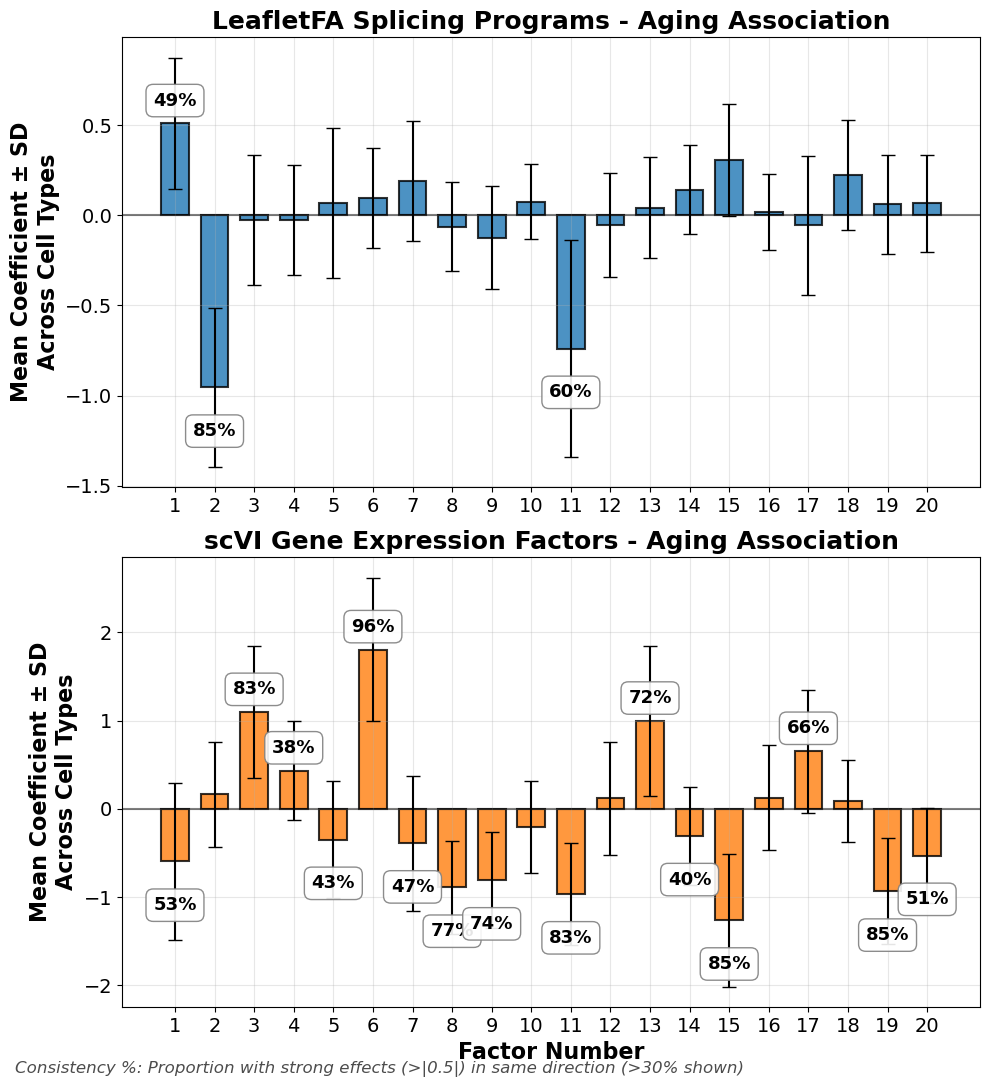

✅ Done! Consistency = % of cell types with strong effects (>|0.5|) in same direction


In [31]:
# Example usage:
create_factor_barplot_summary(feature_importance_df, paths['output_dir'])

In [32]:
def create_forest_plot_single_celltype(feature_df, cell_type, output_dir, top_n_factors=10, figsize=(4, 4)):
    """Create a simple forest plot for a single cell type."""
    
    # Filter and get top factors
    ct_data = feature_df[feature_df['cell_type'] == cell_type].copy()
    ct_data = ct_data.nlargest(top_n_factors, 'abs_coefficient').sort_values('coefficient')
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    colors = {'Splicing': '#1f77b4', 'Gene_Expression': '#ff7f0e'}
    
    for i, (_, row) in enumerate(ct_data.iterrows()):
        ax.errorbar(row['coefficient'], i, 
                   xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]], 
                   fmt='o', color=colors[row['factor_type']], capsize=3, markersize=6, alpha=0.8)
        
        factor_label = row['factor_name']
        ax.text(row['coefficient'], i, f"  {factor_label}", va='center', 
               ha='left' if row['coefficient'] >= 0 else 'right', fontsize=10)
    
    # Format
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Ridge Regression Coefficient ± 95% CI', fontweight='bold', fontsize=11)
    ax.set_ylabel('Top Factors', fontweight='bold', fontsize=11)
    ax.set_title(cell_type, fontweight='bold', fontsize=12)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors['Splicing'], label='LeafletFA'),
                      Patch(facecolor=colors['Gene_Expression'], label='scVI')]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/forest_plot_{cell_type.replace(' ', '_').replace('/', '_')}.pdf", 
                dpi=300, bbox_inches='tight')
    print(f"Saved file to {output_dir}/forest_plot_{cell_type.replace(' ', '_').replace('/', '_')}.pdf")
    plt.show()

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Urogenital_epithelial_cell.pdf


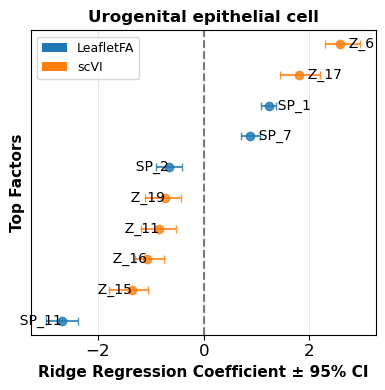

In [33]:
# Panel C: Single cell type forest plot
cell_type="Urogenital epithelial cell"
create_forest_plot_single_celltype(feature_df_ci, cell_type, paths["output_dir"], top_n_factors=10, figsize=(4, 4))

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Skeletal_muscle_cell.pdf


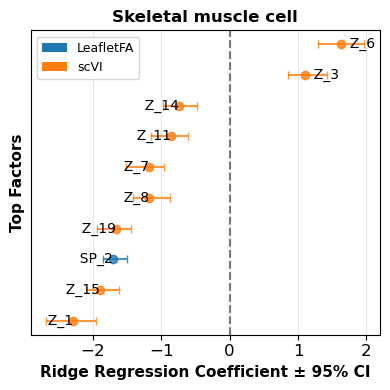

In [34]:
cell_type="Skeletal muscle cell"
create_forest_plot_single_celltype(feature_df_ci, cell_type, paths["output_dir"], top_n_factors=10, figsize=(4, 4))

## Load LeafletFA SP junction markers 
Obtained from `/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/NatureAging_PLOTTING_MOUSE/MOUSE_FIGURE_PLOTS.ipynb`

In [35]:
sj_markers = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/final_df.tsv.gz"
sj_markers_df = pd.read_csv(sj_markers, sep="\t")
sj_markers_df.head()

,old_factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
0,0,0,0.020312,0.020312,0.000079,0.0,0.00,1.00,False,0.2,...,0.9938,0.9752,213472,217533,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1,0,1,-0.020029,0.020029,0.056855,11.0,0.11,0.89,False,0.2,...,0.0242,1.0000,217533,5258,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
2,0,2,0.344711,0.344711,0.000601,100.0,1.00,0.00,True,0.2,...,0.6404,1.0000,313794,200962,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
3,0,3,-0.199744,0.199744,0.000549,42.0,0.42,0.58,False,0.2,...,0.3570,0.3793,313794,295362,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
4,0,4,0.357117,0.357117,0.000835,100.0,1.00,0.00,True,0.2,...,1.0000,0.6170,182253,295362,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated


Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/sj_markers_aging_effect_size.pdf


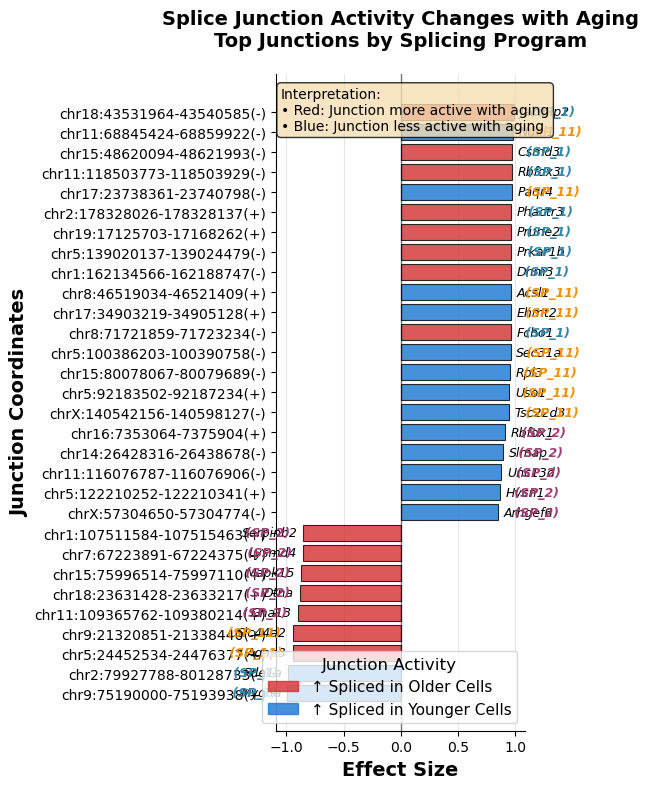

In [36]:
# Set style
plt.style.use('default')

# Define the important factors and their age associations
important_factors = [0, 1, 10]  # SP_1, SP_2, SP_7, SP_11

# Age association direction for each factor (from your feature_df_ci)
age_associations = {
    0: 'positive',   # SP_1: positive coefficient = more active in older cells
    1: 'negative',   # SP_2: negative coefficient = more active in younger cells  
    10: 'negative'   # SP_11: check your feature_df_ci for actual direction
}

# Filter for significant junctions
filtered_df = sj_markers_df[
    (sj_markers_df["factor_idx"].isin(important_factors)) & 
    (sj_markers_df["significant"]) & 
    (sj_markers_df["abs_effect_size"] > 0.25)
].copy()

# Get top N junctions per factor
top_n_per_factor = 10
top_junctions = []
for factor in important_factors:
    factor_data = filtered_df[filtered_df["factor_idx"] == factor]
    if len(factor_data) > 0:
        top_factor_junctions = factor_data.nlargest(top_n_per_factor, 'abs_effect_size')
        top_junctions.append(top_factor_junctions)

plot_data = pd.concat(top_junctions, ignore_index=True)

# Create junction labels
plot_data['junction_label'] = plot_data['junction_id'].str.replace('_', ':', 1).str.replace('_', '-', 1).str.replace('_', '(', 1) + ')'

# Create interpretable effect direction
plot_data['age_direction'] = plot_data.apply(lambda row: 
    'Older' if (age_associations[row['factor_idx']] == 'positive' and row['effect_size'] > 0) or 
              (age_associations[row['factor_idx']] == 'negative' and row['effect_size'] < 0)
    else 'Younger', axis=1)

# Create factor labels with age direction
plot_data['sp_label'] = 'SP_' + (plot_data['factor_idx'] + 1).astype(str)

# Define colors based on age direction instead of just factor
plot_data['color'] = plot_data['age_direction'].map({
    'Older': '#d32f2f',    # Red for increased splicing in older cells
    'Younger': '#1976d2'   # Blue for increased splicing in younger cells
})

# Create the plot
plt.figure(figsize=(6, 8))

# Sort by effect size
plot_data_sorted = plot_data.sort_values('effect_size', ascending=True)

# Create barplot
bars = plt.barh(range(len(plot_data_sorted)), plot_data_sorted['effect_size'], 
                color=plot_data_sorted['color'], 
                alpha=0.8, edgecolor='black', linewidth=0.8)

# Customize labels
plt.yticks(range(len(plot_data_sorted)), 
           plot_data_sorted['junction_label'],
           fontsize=10)

plt.xlabel('Effect Size', fontsize=14, fontweight='bold')
plt.ylabel('Junction Coordinates', fontsize=14, fontweight='bold')
plt.title('Splice Junction Activity Changes with Aging\nTop Junctions by Splicing Program', 
          fontsize=14, fontweight='bold', pad=20)

# Add vertical line at x=0
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Add gene names and SP labels with colored SP text
for i, (bar, row) in enumerate(zip(bars, plot_data_sorted.itertuples())):
    width = bar.get_width()
    gene_name = getattr(row, 'gene_name_y', getattr(row, 'gene_name', 'Unknown'))
    sp_label = f"SP_{getattr(row, 'factor_idx')+1}"
    factor_idx = getattr(row, 'factor_idx')
    
    # Define SP colors for text
    sp_text_colors = {0: '#2E86AB', 1: '#A23B72', 10: '#F18F01'}  # Distinct colors for each SP
    
    # Position at the end of the bar
    x_pos = width + (0.05 if width >= 0 else -0.05)
    
    # Create the label with gene name in black and SP in color
    plt.text(x_pos, bar.get_y() + bar.get_height()/2, 
             gene_name, ha='left' if width >= 0 else 'right', 
             va='center', fontsize=9, style='italic', color='black')
    
    # Add SP label in different color, slightly offset
    sp_x_offset = len(gene_name) * 0.008  # Approximate offset based on gene name length
    sp_x_pos = x_pos + (sp_x_offset if width >= 0 else -sp_x_offset)
    
    plt.text(sp_x_pos, bar.get_y() + bar.get_height()/2, 
             f' ({sp_label})', ha='left' if width >= 0 else 'right', 
             va='center', fontsize=9, style='italic', 
             color=sp_text_colors.get(factor_idx, 'black'), fontweight='bold')

# Create age-direction legend
legend_elements = [
    plt.Rectangle((0,0),1,1, color='#d32f2f', alpha=0.8, label='↑ Spliced in Older Cells'),
    plt.Rectangle((0,0),1,1, color='#1976d2', alpha=0.8, label='↑ Spliced in Younger Cells')
]

plt.legend(handles=legend_elements, title='Junction Activity', title_fontsize=12, fontsize=11, 
           loc='lower right')

# Add text box explaining interpretation
textstr = 'Interpretation:\n• Red: Junction more active with aging\n• Blue: Junction less active with aging'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# Grid and styling
plt.grid(True, alpha=0.3, axis='x')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{paths['output_dir']}/sj_markers_aging_effect_size.pdf", dpi=300, bbox_inches='tight')
# print where plot was saved 
print(f"Plot saved to {paths['output_dir']}/sj_markers_aging_effect_size.pdf")
plt.show()

In [37]:
splicing_aging.layers["denoised_PSI"] = splicing_aging.obsm["X_PHI"] @ splicing_aging.varm["psi_learned"].T

In [38]:
def plot_psi_by_age_violin(splice_adata, junction_idx, OUTPUT_DIR=None, figsize=(4, 4)):
    """
    Create a violin plot showing denoised PSI values by age for a single junction
    """
        
    # Get denoised PSI data and age
    junction_psi = splice_adata.layers["denoised_PSI"][:, junction_idx]  # All cells for this junction
    ages = splice_adata.obs["age_numeric"].values
    junction_id = splice_adata.var["junction_id"].values[junction_idx]

    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'PSI': junction_psi,
        'Age': ages
    })
    
    # Remove any NaN values
    plot_df = plot_df.dropna()
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create violin plot with age as continuous variable
    sns.violinplot(data=plot_df, x='Age', y='PSI', 
                  color='#1976d2', alpha=0.7)
    
    # Customize plot
    title = f'Junction {junction_id}'
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('Age (Months)', fontsize=11, fontweight='bold')
    plt.ylabel('Denoised Junction \nUsage Ratio', fontsize=11, fontweight='bold')

    # Increase tick font size 
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    plt.gca().set_axisbelow(True)
    
    plt.tight_layout()
    if OUTPUT_DIR:
        plt.savefig(f"{OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf", dpi=300, bbox_inches='tight')
        print(f"Plot saved to {OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf")
    plt.show()

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/psi_by_age_violin_chr18_43531964_43540585_-.pdf


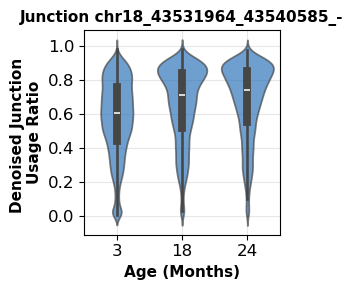

In [39]:
plot_psi_by_age_violin(splicing_aging, junction_idx=13111, OUTPUT_DIR=paths["output_dir"], figsize=(3, 3))

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/psi_by_age_violin_chr9_75190000_75193938_+.pdf


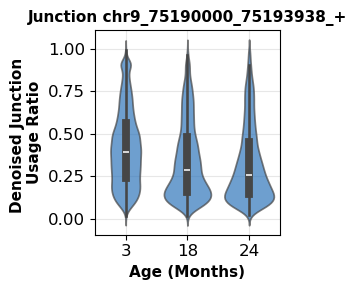

In [40]:
plot_psi_by_age_violin(splicing_aging, junction_idx=33890, OUTPUT_DIR=paths["output_dir"], figsize=(3, 3))

In [41]:
feature_importance_df[feature_importance_df["factor_type"] == "Splicing"].sort_values(by="coefficient", ascending=False)[0:20]

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
1094,Astrocyte,Splicing,SP_15,1.609096,1.609096,0.480790,3.362688e-11
960,Pericyte,Splicing,SP_1,1.345583,1.345583,0.483798,4.933601e-09
1680,Bladder cell,Splicing,SP_1,1.284431,1.284431,0.600993,5.884182e-15
360,Secretory cell,Splicing,SP_1,1.243150,1.243150,0.713702,2.677200e-02
600,Urogenital epithelial cell,Splicing,SP_1,1.235306,1.235306,0.661427,1.110223e-16
1844,Alveolar epithelial cell,Splicing,SP_5,1.124904,1.124904,0.691514,1.468615e-02
46,Skin epithelial cell,Splicing,SP_7,1.019922,1.019922,0.630622,1.110223e-16
1320,Mesenchymal stem cell,Splicing,SP_1,0.996507,0.996507,0.613612,1.110223e-16
1097,Astrocyte,Splicing,SP_18,0.976424,0.976424,0.480790,3.362688e-11
1602,Pancreatic exocrine cell,Splicing,SP_3,0.976063,0.976063,0.370202,5.869858e-02


In [42]:
feature_importance_df[feature_importance_df["factor_type"] == "Splicing"].sort_values(by="coefficient", ascending=True)[0:20]

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
610,Urogenital epithelial cell,Splicing,SP_11,-2.688875,2.688875,0.661427,1.110223e-16
1210,Specialized intestinal cell,Splicing,SP_11,-2.158836,2.158836,0.455352,1.110223e-16
1444,Other neuron,Splicing,SP_5,-2.046895,2.046895,0.390021,1.206510e-09
841,Skeletal muscle cell,Splicing,SP_2,-1.708600,1.708600,0.675371,1.110223e-16
50,Skin epithelial cell,Splicing,SP_11,-1.664226,1.664226,0.630622,1.110223e-16
10,Respiratory epithelial cell,Splicing,SP_11,-1.633938,1.633938,0.441249,1.335029e-06
1681,Bladder cell,Splicing,SP_2,-1.608364,1.608364,0.600993,5.884182e-15
801,Kidney epithelial cell,Splicing,SP_2,-1.601599,1.601599,0.488946,1.110223e-16
250,Intestinal epithelial cell,Splicing,SP_11,-1.582027,1.582027,0.511405,1.110223e-16
361,Secretory cell,Splicing,SP_2,-1.567470,1.567470,0.713702,2.677200e-02


## RBP analysis FIgure 4 !

In [43]:
SP1_cells = feature_importance_df[feature_importance_df["factor_name"] == "SP_1"].sort_values(by="coefficient", ascending=False)[0:20]
SP2_cells = feature_importance_df[feature_importance_df["factor_name"] == "SP_2"].sort_values(by="coefficient", ascending=True)[0:20]

In [44]:
# Keep only where combined_r2 > 0.5 and p_vs_scvi < 0.05
SP1_cells = SP1_cells[SP1_cells["combined_r2"] >= 0.4]
SP2_cells = SP2_cells[SP2_cells["combined_r2"] >= 0.4]
SP1_cells = SP1_cells[SP1_cells["p_vs_scvi"] < 0.05]
SP2_cells = SP2_cells[SP2_cells["p_vs_scvi"] < 0.05]

In [46]:
assert all(ge_adata_aging.obs_names == splicing_aging.obs_names)

In [47]:
ge_adata_aging.layers["scVI_linear"] = ge_adata_aging.obsm["X_normalized_scVI_linear"]

### Running RBP expression vs SP1, SP2 and age correlation

In [51]:
# 2. Get overlapping cell types between SP1 and SP2
sp1_cell_types = set(SP1_cells['cell_type'].values)
sp2_cell_types = set(SP2_cells['cell_type'].values)
overlapping_cell_types = list(sp1_cell_types & sp2_cell_types)
print(f"\nOverlapping cell types: {overlapping_cell_types}")

# 1. Extract RBP genes and their expression
print("Extracting RBP genes...")
rbp_genes = ge_adata_aging.var[ge_adata_aging.var['is_rbp']].index.tolist()
print(f"Found {len(rbp_genes)} RBP genes")

# 3. Ensure SP scores are in ge_adata
if 'SP_1' not in ge_adata_aging.obs.columns:  
    # Match cells between splice_adata and ge_adata
    ge_adata_aging.obs.loc[:, 'SP_1'] = splicing_aging.obs.loc[:, 'SP_1']   
    ge_adata_aging.obs.loc[:, 'SP_2'] = splicing_aging.obs.loc[:, 'SP_2']


Overlapping cell types: ['Secretory cell', 'Pericyte', 'Microglia', 'Dendritic cell', 'Bladder cell', 'Skeletal muscle cell', 'Immune progenitor', 'Stromal cell', 'Mesenchymal stem cell', 'Skin epithelial cell', 'Endothelial cell']
Extracting RBP genes...
Found 287 RBP genes


In [ ]:
import pingouin as pg

# === pick one cell type and one RBP ===
cell_type = "Microglia"     # <-- change
rbp_gene  = "HNRNPH1"       # <-- change

# 0) Ensure SP_1/SP_2 are in ge_adata_aging.obs, aligned to obs_names
for col in ["SP_1", "SP_2"]:
    if col not in ge_adata_aging.obs.columns:
        ge_adata_aging.obs[col] = (
            splicing_aging.obs[col].reindex(ge_adata_aging.obs_names).values
        )

# 1) Subset to chosen cell type
mask = ge_adata_aging.obs["medium_cell_type"] == cell_type
ct = ge_adata_aging[mask].copy()
print(f"{cell_type}: {ct.n_obs} cells")

# 2) Pull RBP expression vector (mediator)
if "scVI_linear" in ct.layers:
    Xg = ct[:, rbp_gene].layers["scVI_linear"]
else:
    Xg = ct[:, rbp_gene].X
rbp_expr = np.asarray(Xg.todense() if hasattr(Xg, "todense") else Xg).ravel()

# 3) Build analysis DataFrame (no covariates)
df = pd.DataFrame({
    "Age":      ct.obs["age_numeric"].values,
    "RBP_expr": rbp_expr,
    "SP1":      ct.obs["SP_1"].values,
    "SP2":      ct.obs["SP_2"].values,
})

df["SPdiff"] = df["SP1"] - df["SP2"]
# positive SPdiff means SP1 is higher than SP2 

def run_mediation(ycol):
    d = df[["Age", "RBP_expr", ycol]].dropna().rename(columns={ycol: "Y"})
    if d["RBP_expr"].std() == 0 or d["Y"].std() == 0:
        print(f"{ycol}: zero variance; skipping")
        return None
    res = pg.mediation_analysis(
        data=d, x="Age", m="RBP_expr", y="Y",
        n_boot=2000, seed=42  # increase n_boot for publication
    )
    out = res.copy()
    out.insert(0, "Outcome", ycol)
    out.insert(1, "CellType", cell_type)
    out.insert(2, "RBP", rbp_gene)
    return out

out = pd.concat(
    [r for r in (run_mediation("SP1"),
                 run_mediation("SP2"),
                 run_mediation("SPdiff")) if r is not None],
    ignore_index=True
)

print(out)

Microglia: 12060 cells
   Outcome   CellType      RBP          path        coef            se  \
0      SP1  Microglia  HNRNPH1  RBP_expr ~ X   -0.000002  3.878197e-08   
1      SP1  Microglia  HNRNPH1  Y ~ RBP_expr -195.903315  2.592675e+01   
2      SP1  Microglia  HNRNPH1         Total    0.002896  1.221241e-04   
3      SP1  Microglia  HNRNPH1        Direct    0.003134  1.377936e-04   
4      SP1  Microglia  HNRNPH1      Indirect   -0.000238  8.819685e-05   
5      SP2  Microglia  HNRNPH1  RBP_expr ~ X   -0.000002  3.878197e-08   
6      SP2  Microglia  HNRNPH1  Y ~ RBP_expr  242.304594  1.392477e+01   
7      SP2  Microglia  HNRNPH1         Total   -0.002279  6.452369e-05   
8      SP2  Microglia  HNRNPH1        Direct   -0.002216  7.283367e-05   
9      SP2  Microglia  HNRNPH1      Indirect   -0.000063  3.988069e-05   
10  SPdiff  Microglia  HNRNPH1  RBP_expr ~ X   -0.000002  3.878197e-08   
11  SPdiff  Microglia  HNRNPH1  Y ~ RBP_expr -438.207909  3.406591e+01   
12  SPdiff  Mic

In [ ]:
# 4. Calculate correlations for each cell type
all_correlations = []

for cell_type in tqdm(overlapping_cell_types, desc="Processing cell types"):
    # Subset to this cell type
    cell_mask = ge_adata.obs['medium_cell_type'] == cell_type
    ct_adata = ge_adata[cell_mask]
    
    # Get RBP expression (using scVI_linear if available)
    rbp_expr = ct_adata[:, rbp_genes].layers['scVI_linear']
    
    # Convert to dense if sparse
    if hasattr(rbp_expr, 'todense'):
        rbp_expr = np.array(rbp_expr.todense())
    
    # Get metadata
    sp1_values = ct_adata.obs['SP_1'].values
    sp2_values = ct_adata.obs['SP_2'].values
    age_values = ct_adata.obs['age_numeric'].values
    
    # Calculate correlations for each RBP
    for i, rbp in enumerate(rbp_genes):
        rbp_expression = rbp_expr[:, i].flatten()
        
        # Skip if no variation
        if np.std(rbp_expression) == 0:
            continue
        
        # Calculate correlations
        sp1_cor, sp1_p = spearmanr(rbp_expression, sp1_values)
        sp2_cor, sp2_p = spearmanr(rbp_expression, sp2_values)
        age_cor, age_p = spearmanr(rbp_expression, age_values)
        
        all_correlations.append({
            'cell_type': cell_type,
            'RBP': rbp,
            'SP1_cor': sp1_cor,
            'SP1_pval': sp1_p,
            'SP2_cor': sp2_cor,
            'SP2_pval': sp2_p,
            'Age_cor': age_cor,
            'Age_pval': age_p,
            'n_cells': ct_adata.n_obs
        })

# 5. Convert to DataFrame
corr_df = pd.DataFrame(all_correlations)
print(f"\nCalculated {len(corr_df)} correlations")

# 6. Apply FDR correction per cell type
for cell_type in corr_df['cell_type'].unique():
    ct_mask = corr_df['cell_type'] == cell_type
    
    # FDR for SP1
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        corr_df.loc[ct_mask, 'SP1_pval'], method='fdr_bh'
    )
    corr_df.loc[ct_mask, 'SP1_fdr'] = pvals_corrected
    
    # FDR for SP2
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        corr_df.loc[ct_mask, 'SP2_pval'], method='fdr_bh'
    )
    corr_df.loc[ct_mask, 'SP2_fdr'] = pvals_corrected
    
    # FDR for Age
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        corr_df.loc[ct_mask, 'Age_pval'], method='fdr_bh'
    )
    corr_df.loc[ct_mask, 'Age_fdr'] = pvals_corrected

# 7. Filter for significant correlations
print(f"Filtering for significant correlations with SP1 and SP2 using threshold of absolute effect size > 0.2 and FDR < 0.05")
significant_mask = (
    (np.abs(corr_df['SP1_cor']) > 0.2) & (corr_df['SP1_fdr'] < 0.05)
) | (
    (np.abs(corr_df['SP2_cor']) > 0.2) & (corr_df['SP2_fdr'] < 0.05)
)

sig_corr_df = corr_df[significant_mask].copy()
print(f"\n{len(sig_corr_df)} significant correlations (|rho| > 0.2, FDR < 0.05)")

# 8. Identify RBPs with opposite correlations to SP1 vs SP2
print(f"Identifying RBPs with opposite correlations to SP1 vs SP2")
sig_corr_df['opposite_sign'] = sig_corr_df['SP1_cor'] * sig_corr_df['SP2_cor'] < 0
sig_corr_df['opposite_strength'] = np.abs(sig_corr_df['SP1_cor'] - sig_corr_df['SP2_cor'])

# Filter for strong opposite effects
print(f"Filtering for strong opposite effects with absolute effect size > 0.2 and FDR < 0.05")
opposite_rbps = sig_corr_df[
    (sig_corr_df['opposite_sign']) & 
    (np.abs(sig_corr_df['SP1_cor']) > 0.2) & 
    (np.abs(sig_corr_df['SP2_cor']) > 0.2) &
    (sig_corr_df['SP1_fdr'] < 0.05) &
    (sig_corr_df['SP2_fdr'] < 0.05)
].copy()

print(f"\n{len(opposite_rbps)} RBP-cell type pairs with opposite correlations")
print(f"Unique RBPs with opposite effects: {opposite_rbps['RBP'].nunique()}")

# 9. Get top opposing RBPs across cell types
rbp_summary = opposite_rbps.groupby('RBP').agg({
    'SP1_cor': 'mean',
    'SP2_cor': 'mean',
    'opposite_strength': 'mean',
    'cell_type': 'count'
}).rename(columns={'cell_type': 'n_cell_types'})

rbp_summary = rbp_summary.sort_values(by=["n_cell_types", "opposite_strength"], ascending=False)
print("\nTop RBPs with opposite SP1/SP2 correlations:")

# 10. Visualization of top opposing RBPs
print(f"The top 50 RBPs with opposite SP1/SP2 correlations are:")
top_opposing_rbps = rbp_summary.head(50).index.tolist()
print(rbp_summary.head(50))

### Create heatmap of RBP correlation with SP1-SP2 (where RBP correlation is opposite in these two splicing programs)

In [ ]:
# Create heatmap data
heatmap_data_sp1 = []
heatmap_data_sp2 = []

print(f"Looking at {len(overlapping_cell_types)} cell types which are {overlapping_cell_types}")
print(f"Still considering {len(top_opposing_rbps)} top opposing (opposite correlations in SP1 and SP2) RBPs which are {top_opposing_rbps}")

for ct in overlapping_cell_types:
    sp1_row = []
    sp2_row = []
    for rbp in top_opposing_rbps:
        mask = (corr_df['cell_type'] == ct) & (corr_df['RBP'] == rbp)
        if mask.sum() > 0:
            sp1_row.append(corr_df.loc[mask, 'SP1_cor'].values[0])
            sp2_row.append(corr_df.loc[mask, 'SP2_cor'].values[0])
        else:
            sp1_row.append(np.nan)
            sp2_row.append(np.nan)
    heatmap_data_sp1.append(sp1_row)
    heatmap_data_sp2.append(sp2_row)

# Create dataframes for the heatmaps
df_sp1 = pd.DataFrame(heatmap_data_sp1, 
                      index=overlapping_cell_types, 
                      columns=top_opposing_rbps)

df_sp2 = pd.DataFrame(heatmap_data_sp2,
                      index=overlapping_cell_types,
                      columns=top_opposing_rbps)

df_diff = df_sp1 - df_sp2

In [ ]:
# Transpose dataframes so RBPs are rows and cell types are columns
df_sp1_T = df_sp1.T  # RBPs as rows, cell types as columns
df_sp2_T = df_sp2.T
df_diff_T = df_diff.T
sp1 = "SP_1"
sp2 = "SP_2"

# Adjust figure size for better readability with RBPs as rows
figsize = (6, 8)

print(f"Creating clustermaps with {df_sp1_T.shape[0]} RBPs and {df_sp1_T.shape[1]} cell types")

# SP1 clustermap
g1 = sns.clustermap(df_sp1_T,
                     cmap='PRGn', center=0, 
                     figsize=figsize,
                     cbar_kws={'label': 'Correlation with SP1'},
                     row_cluster=True,
                     col_cluster=True,
                     linecolor='gray',
                     yticklabels=True,  # Show all RBP labels
                     xticklabels=True)   # Show all cell type labels
g1.ax_heatmap.set_xlabel('Cell Type', fontsize=12)
g1.ax_heatmap.set_ylabel('RBP', fontsize=12)
g1.ax_heatmap.tick_params(axis='y', labelsize=8)  # Smaller font for RBP names
g1.ax_heatmap.tick_params(axis='x', labelsize=8, rotation=45)
plt.show()

# SP2 clustermap
g2 = sns.clustermap(df_sp2_T,
                     cmap='PRGn', center=0, 
                     figsize=figsize,
                     cbar_kws={'label': 'Correlation with SP2'},
                     row_cluster=True,
                     col_cluster=True,
                     linecolor='gray',
                     yticklabels=True,
                     xticklabels=True)
g2.ax_heatmap.set_xlabel('Cell Type', fontsize=12)
g2.ax_heatmap.set_ylabel('RBP', fontsize=12)
g2.ax_heatmap.tick_params(axis='y', labelsize=8)
g2.ax_heatmap.tick_params(axis='x', labelsize=10, rotation=45)
plt.show()

# Create difference heatmap (SP1 - SP2)
g3 = sns.clustermap(df_diff_T,
                     cmap='PRGn', center=0,
                     figsize=figsize,
                     cbar_kws={'label': 'SP1 - SP2 Correlation Difference'},
                     row_cluster=True,
                     col_cluster=True,
                     linecolor='gray',
                     yticklabels=True,
                     xticklabels=True)
g3.ax_heatmap.set_xlabel('Cell Type', fontsize=12)
g3.ax_heatmap.set_ylabel('RBP', fontsize=12)
g3.ax_heatmap.tick_params(axis='y', labelsize=8)
g3.ax_heatmap.tick_params(axis='x', labelsize=10, rotation=45)

outname = f"SP_{sp1}_SP_{sp2}_top_RBP_correlations_clustermap.pdf"
clustermap_path = os.path.join(paths["output_dir"], outname)
# Save the clustermap
g3.savefig(clustermap_path, dpi=300, bbox_inches='tight')
print(f"Clustermap saved to: {clustermap_path}")
plt.show()

In [ ]:
# Get the cell activity data from ge_adata
# Assuming SP1 and SP2 scores are in ge_adata.obs
plot_data = splice_adata.obs[['medium_cell_type', 'SP_1', 'SP_2', 'age_numeric']].copy()

# Filter for just the overlapping cell types
plot_data = plot_data[plot_data['medium_cell_type'].isin(overlapping_cell_types)]
print(plot_data)

# Calculate and print statistics
print("=== SP1 vs SP2 Relationship Statistics ===")
for cell_type in overlapping_cell_types:
    ct_data = plot_data[plot_data['medium_cell_type'] == cell_type]
    corr = ct_data['SP_1'].corr(ct_data['SP_2'])
    print(f"{cell_type}: r={corr:.3f}, n={len(ct_data)} cells")

overall_corr = plot_data['SP_1'].corr(plot_data['SP_2'])
print(f"\nOverall correlation: r={overall_corr:.3f}")

# Melt SP1 and SP2 into long format for split violin plotting
# ensure medium_cell_type is characte not categorical
plot_data["medium_cell_type"] = plot_data["medium_cell_type"].astype(str)
print(f"Generating violin plot of SP1 and SP2 activity across cell types for figure 4 to show antagonistic splicing programs")
long_df = plot_data.melt(
    id_vars='medium_cell_type',
    value_vars=['SP_1', 'SP_2'],
    var_name='Program',
    value_name='Activity'
)

# Order cell types by SP_1 median for clarity 
order = (
    plot_data.groupby("medium_cell_type")["SP_1"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Initialize figure
fig, ax = plt.subplots(figsize=(4, 5))

# Plot split violins
sns.violinplot(
    data=long_df,
    x="medium_cell_type",
    y="Activity",
    hue="Program",
    split=True,
    inner="quartile",
    linewidth=1,
    order=order,
    ax=ax
)

# Aesthetics
ax.set_title("Antagonistic Aging \nSplicing Programs", fontsize=13, fontweight="bold")
ax.set_xlabel("Cell Type", fontsize=13)
ax.set_ylabel("Program Activity", fontsize=13)
ax.tick_params(axis='x', rotation=45)
# increase fontsize of of all ticks 
ax.tick_params(axis='both', labelsize=12)
ax.legend(title="", loc='upper right', frameon=False, fontsize=13)

plt.tight_layout()
# save figure
plt.savefig(os.path.join(paths["output_dir"], "SP1_SP2_violin_plot.pdf"), dpi=300)
# print figure  
print(f"Saved figure to {paths['output_dir']}/SP1_SP2_violin_plot.pdf")
plt.show()

### Calculating RBP correlations with top splice junctions from SP1 and SP2 (Figure 4 ctd)

In [49]:
# top_opposing_rbps, overlapping_cell_types

In [ ]:
# Step 1: Start from filtered significant RBPs
sig_rbps_df = corr_df[corr_df["RBP"].isin(top_opposing_rbps)]

# Step 2: Count how many cell types each RBP appears in
rbp_counts = (
    sig_rbps_df.groupby("RBP")
    .agg(
        n_cell_types=("cell_type", "nunique"),
        mean_abs_age_cor=("Age_cor", lambda x: np.mean(np.abs(x))),
        median_age_cor=("Age_cor", "median")
    )
    .reset_index()
)

# Step 3: Rank RBPs by # of cell types (descending), then by mean_abs_age_cor
rbp_counts = rbp_counts.sort_values(
    by=["n_cell_types", "mean_abs_age_cor"], ascending=[False, False]
)

print(rbp_counts.head())
print(rbp_counts["RBP"].nunique())

In [ ]:
# Step 5: Filter sig_rbps_df to only include top RBPs same RBPs as in other panel looking at overall RBP correlation with SP1/SP2
plot_df = sig_rbps_df.copy()

# Step 6: Compute absolute effect size for dot size
plot_df['Age_cor_abs'] = plot_df['Age_cor'].abs()

# Step 7: Order RBPs by mean correlation (or keep top_50_rbps order)
rbp_order = (
    plot_df.groupby("RBP")["Age_cor"]
    .mean()
    .sort_values()
    .index
)

# Step 8: Set RBP as ordered categorical for plotting
plot_df["RBP"] = pd.Categorical(plot_df["RBP"], categories=rbp_order, ordered=True)
plot_df

### Plot of RBP correlations with age across cell types of interest

In [ ]:
# Step 1: Subset corr_df to only these RBPs (not just sig ones)
clustermap_df = corr_df[
    corr_df["RBP"].isin(top_opposing_rbps)
].copy()

# Step 2: Pivot to RBP × cell_type matrix of Age_cor
heatmap_data = clustermap_df.pivot(
    index="cell_type", columns="RBP", values="Age_cor"
)

# Step 3: Ensure correct RBP column order (optional: by mean age correlation)
ordered_rbps = (
    heatmap_data.mean().sort_values().index
)
heatmap_data = heatmap_data[ordered_rbps]

# Step 4: Handle missing data (optional: fill with 0, or keep NaNs and mask)
heatmap_data_filled = heatmap_data.fillna(0)  # or use .dropna() if you want full matrix only

g = sns.clustermap(
    data=heatmap_data_filled,
    cmap="PRGn",  # purple-green for down/up with age
    center=0,
    figsize=(10, 8),
    row_cluster=True,
    col_cluster=True,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Age correlation (Spearman)"}
)

# Step 6: Label formatting
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_ylabel("Cell Type", fontsize=12)
g.ax_heatmap.set_xlabel("RNA-binding Protein", fontsize=12)

plt.tight_layout()
plt.show()

### Identify top SJ per program in SP1 and SP2 and correlate their denoised usage ratio with RBP activity

In [53]:
final_df = sj_markers_df

# Define parameters
top_n = 50
sp1 = 0
sp2 = 1

# Step 1: Get top 50 for SP1 (by abs effect size)
sp1_top = (
    sj_markers_df[sj_markers_df["factor_idx"] == sp1]
    .copy()
    .assign(abs_effect_size=lambda df: df["effect_size"].abs())
    .sort_values("abs_effect_size", ascending=False)
    .head(top_n)
)

# Step 2: Get top 50 for SP2 (by raw effect size)
sp2_top = (
    sj_markers_df[sj_markers_df["factor_idx"] == sp2]
    .sort_values("effect_size", ascending=False)
    .head(top_n)
)

# Step 3: Combine and extract junction indices
top_junctions = pd.concat([sp1_top, sp2_top], ignore_index=True)
top_junction_ids = top_junctions["junction_id_index"].unique()

# Step 4: Extract all factor effects on those junctions
junction_specific_df = final_df[final_df["junction_id_index"].isin(top_junction_ids)].copy()

In [ ]:
label_colors_map = {"Aging": "gold", "RBP": "lightgreen", "Aging+RBP": "orange", "Other": "lightgray"}

# Subset only to SP1 and SP2
factors_to_keep = [sp1, sp2]
junction_specific_df = junction_specific_df[junction_specific_df["factor_idx"].isin(factors_to_keep)]

if not junction_specific_df.empty and len(junction_specific_df["factor_idx"].unique()) > 1:

    # Pivot: junctions × [sp1, sp2]
    clustermap_data = junction_specific_df.pivot_table(
        index=["junction_id_index", "gene_name_x", "junction_label"],
        columns="factor_idx",
        values="effect_size",
        fill_value=0
    )

    # Restrict columns to SP1 and SP2 only
    clustermap_data = clustermap_data[[sp1, sp2]]

    # Rename columns
    clustermap_data.columns = [f"SP_{sp1+1}", f"SP_{sp2+1}"]

    # Row colors for junction types
    junction_types_for_colors = clustermap_data.index.get_level_values("junction_label")
    row_color_series = junction_types_for_colors.map(label_colors_map).rename("Junction Type")
    row_colors_df = row_color_series.to_frame()

    # Clean display labels for y-axis
    display_row_labels = [f"{gene} (J{jid})" for jid, gene, _ in clustermap_data.index]
    clustermap_data_display = clustermap_data.copy()
    clustermap_data_display.index = display_row_labels
    row_colors_df.index = display_row_labels

    # Clustermap
    g = sns.clustermap(
        clustermap_data_display,
        row_colors=row_colors_df,
        cmap="PRGn",
        center=0,
        annot=False,
        figsize=(6, 8),
        cbar_kws={'label': 'Effect Size'},
        xticklabels=True,
        yticklabels=True
    )

    # Customize tick labels
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)

    # Title
    g.fig.suptitle(
        f'Effect Sizes for Top {len(top_junction_ids)} Junctions\n(Factors SP_{sp1+1} and SP_{sp2+1})',
        fontsize=12, fontweight='bold', y=0.98
    )

    # Junction label legend
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color, label=label)
        for label, color in label_colors_map.items()
        if label in junction_types_for_colors.values
    ]
    g.fig.legend(
        handles=legend_handles,
        title="Junction Type",
        loc="upper left",
        bbox_to_anchor=(0.02, 0.95),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

    # Save plot
    outname = f"SP_{sp1+1}_SP_{sp2+1}_top_junctions_clustermap.pdf"
    clustermap_path = os.path.join(paths['output_dir'], outname)
    print(f"Plot saved to {clustermap_path}")
    g.savefig(clustermap_path, dpi=300, bbox_inches='tight')
    plt.show()

## RBPs vs Splice Junctions

In [55]:
def classify_junction_behavior(sp1_eff, sp2_eff, threshold=0.25):
    """
    Classify junction behavior based on effect sizes from SP1 (aging) and SP2 (youth):
    
    - 'aging_promoting':     SP1+ and SP2− → increased usage in aging program, decreased in youth
    - 'youth_maintaining':   SP1− and SP2+ → decreased in aging, enriched in youth
    - 'concordant_up':       SP1+ and SP2+ → globally increased across programs
    - 'concordant_down':     SP1− and SP2− → globally decreased
    - 'ambiguous':           weak effects or conflicting signs
    """
    # Apply soft threshold to filter out weak effects
    if abs(sp1_eff) < threshold and abs(sp2_eff) < threshold:
        return "ambiguous"

    if sp1_eff > threshold and sp2_eff < -threshold:
        return "aging_promoting"
    elif sp1_eff < -threshold and sp2_eff > threshold:
        return "youth_maintaining"
    elif sp1_eff > threshold and sp2_eff > threshold:
        return "concordant_up"
    elif sp1_eff < -threshold and sp2_eff < -threshold:
        return "concordant_down"
    else:
        return "ambiguous"

def build_effect_size_lookup(df, col="effect_size"):
    return {row["junction_id_index"]: row[col] for _, row in df.iterrows()}


def analyze_rbp_junction_sp1_sp2_refined(splice_adata, ge_adata, final_df,
                                         overlapping_cell_types, rbp_counts,
                                         sp1_idx=0, sp2_idx=1,
                                         cor_threshold=0.3, fdr_threshold=0.05,
                                         min_cell_types=5):
    """
    Improved RBP-junction association analysis with SP1/SP2 aging directionality.
    """
    from statsmodels.stats.multitest import multipletests
    import numpy as np
    import pandas as pd
    import scipy.stats as stats
    from scipy.stats import rankdata

    print("⏳ Preparing data...")
    sig_df = final_df[final_df["significant"]]
    sp1_df = sig_df[sig_df["factor_idx"] == sp1_idx]
    sp2_df = sig_df[sig_df["factor_idx"] == sp2_idx]
    
    sp1_juncs = set(sp1_df["junction_id_index"])
    sp2_juncs = set(sp2_df["junction_id_index"])
    overlap = sp1_juncs & sp2_juncs
    print(f"SP1: {len(sp1_juncs)}, SP2: {len(sp2_juncs)}, Overlap: {len(overlap)}")

    # Dictionaries of effect sizes
    sp1_eff_dict = build_effect_size_lookup(sp1_df)
    sp2_eff_dict = build_effect_size_lookup(sp2_df)

    # Classify overlapping junctions
    junction_annotations = {
        junc: classify_junction_behavior(sp1_eff_dict[junc], sp2_eff_dict[junc])
        for junc in overlap
    }
    junction_annotation_series = pd.Series(junction_annotations).value_counts()
    print("\n🧠 Junction Behavior Categories (overlap only):")
    print(junction_annotation_series)

    # Prepare matrices
    cell_mask = splice_adata.obs["medium_cell_type"].isin(overlapping_cell_types)
    splice_subset = splice_adata[cell_mask]
    ge_subset = ge_adata[cell_mask]

    all_junctions = np.array(list(sp1_juncs | sp2_juncs))
    if 'denoised_PSI' in splice_subset.layers:
        X = splice_subset[:, all_junctions].layers["denoised_PSI"]
    else:
        X = splice_subset[:, all_junctions].X
    if hasattr(X, "todense"): X = np.array(X.todense())

    rbps = rbp_counts[rbp_counts["n_cell_types"] >= min_cell_types]["RBP"].unique()
    rbps = [rbp for rbp in rbps if rbp in ge_subset.var_names]
    Y = ge_subset[:, rbps].layers["scVI_linear"]
    if hasattr(Y, "todense"): Y = np.array(Y.todense())

    print(f"Junction expr: {X.shape}, RBP expr: {Y.shape}")

    # Clean
    junc_std = X.std(axis=0)
    rbp_std = Y.std(axis=0)
    # X is junctions, Y is RBPs
    X = X[:, junc_std > 0]
    Y = Y[:, rbp_std > 0]
    kept_junctions = all_junctions[junc_std > 0]
    kept_rbps = [rbps[i] for i, keep in enumerate(rbp_std > 0) if keep]

    # Spearman rank transform
    def fast_spearman(X, Y):
        Xr = np.apply_along_axis(rankdata, 0, X)
        Yr = np.apply_along_axis(rankdata, 0, Y)
        Xc = Xr - Xr.mean(0)
        Yc = Yr - Yr.mean(0)
        Xn = Xc / Xr.std(0)
        Yn = Yc / Yr.std(0)
        corr = (Yn.T @ Xn) / (Xn.shape[0] - 1)
        t = corr * np.sqrt((Xn.shape[0] - 2) / (1 - corr ** 2 + 1e-8))
        pval = 2 * (1 - stats.t.cdf(np.abs(t), df=Xn.shape[0] - 2))
        return corr, pval

    print("⚙️ Computing Spearman correlations...")
    corr_mat, pval_mat = fast_spearman(X, Y)

    # Build output
    rbp_summaries = []
    rbp_junction_records = []

    for i, rbp in enumerate(kept_rbps):
        corrs = corr_mat[i, :]
        pvals = pval_mat[i, :]
        _, qvals, _, _ = multipletests(pvals, method="fdr_bh")
        sig = (np.abs(corrs) > cor_threshold) & (qvals < fdr_threshold)

        if not np.any(sig): continue

        summary = {
            "RBP": rbp,
            "n_total_sig": int(sig.sum()),
            "sp1_only": 0,
            "sp2_only": 0,
            "aging_promoting": 0,
            "youth_maintaining": 0,
            "concordant_up": 0,
            "concordant_down": 0,
            "ambiguous": 0  # ← add this
        }
        
        for j, valid in enumerate(sig):
            if not valid: continue
            junc_id = kept_junctions[j]
            corr_val = corrs[j]

            # Annotate
            if junc_id in overlap:
                category = junction_annotations[junc_id]
                summary[category] += 1
            elif junc_id in sp1_juncs:
                summary["sp1_only"] += 1
                category = "sp1_only"
            elif junc_id in sp2_juncs:
                summary["sp2_only"] += 1
                category = "sp2_only"
            else:
                category = "unknown"

            rbp_junction_records.append({
                "RBP": rbp,
                "junction_id": junc_id,
                "correlation": corr_val,
                "category": category,
                "sp1_effect": sp1_eff_dict.get(junc_id, np.nan),
                "sp2_effect": sp2_eff_dict.get(junc_id, np.nan)
            })

        rbp_summaries.append(summary)

    results_df = pd.DataFrame(rbp_summaries).sort_values("n_total_sig", ascending=False)
    junction_corr_df = pd.DataFrame(rbp_junction_records)
    junction_cat_df = pd.DataFrame.from_dict(junction_annotations, orient="index", columns=["category"])

    print(f"\n✅ RBPs with at least one significant correlation: {len(results_df)}")
    print(results_df.head(10))

    return results_df, junction_corr_df, junction_cat_df


In [ ]:
results_df, junction_corr_df, junction_cat_df = analyze_rbp_junction_sp1_sp2_refined(splice_adata, ge_adata, final_df,
                                         overlapping_cell_types, rbp_counts,
                                         sp1_idx=0, sp2_idx=1,
                                         cor_threshold=0.3, fdr_threshold=0.05,
                                         min_cell_types=5)

In [57]:
from matplotlib.patches import Patch

def plot_stacked_rbp_summary(results_df, top_n=20, output_dir=None, figsize=(8, 6)):
    """
    Plot stacked barplot showing breakdown of significant junction categories per RBP.
    Emphasizes aging_promoting and youth_maintaining junctions.
    """
    # Select top RBPs
    top_rbps = results_df.sort_values("n_total_sig", ascending=False).head(top_n).copy()

    # Categories to show
    category_order = [
        "aging_promoting", "youth_maintaining",
        "concordant_up", "concordant_down",
        "sp1_only", "sp2_only", "ambiguous"
    ]

    category_colors = {
        "aging_promoting": "#d73027",        # red
        "youth_maintaining": "#4575b4",      # blue
        "concordant_up": "#91bfdb",          # light blue
        "concordant_down": "#fc8d59",        # light red
        "sp1_only": "#e0e0e0",               # light gray
        "sp2_only": "#c7c7c7",               # medium gray
        "ambiguous": "#969696",              # dark gray
    }

    # Initialize bar segments
    bottoms = [0] * len(top_rbps)
    fig, ax = plt.subplots(figsize=figsize)

    # Plot each category as a horizontal bar segment
    for cat in category_order:
        values = top_rbps[cat].values
        ax.barh(top_rbps["RBP"], values, left=bottoms, color=category_colors[cat], label=cat.replace("_", " ").title())
        bottoms = [b + v for b, v in zip(bottoms, values)]

    # Formatting
    ax.set_xlabel("Number of Significant Junctions", fontsize=12)
    ax.set_ylabel("RBP", fontsize=12)
    ax.set_title(f"Top {top_n} RBPs: Significant Junctions", fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=11)

    # Custom legend
    custom_legend = [
        Patch(facecolor=category_colors["aging_promoting"], label="↑ Spliced in Older Cells"),
        Patch(facecolor=category_colors["youth_maintaining"], label="↑ Spliced in Younger Cells"),
        Patch(facecolor=category_colors["concordant_up"], label="Concordant ↑"),
        Patch(facecolor=category_colors["concordant_down"], label="Concordant ↓"),
        Patch(facecolor=category_colors["sp1_only"], label="SP1 Only"),
        Patch(facecolor=category_colors["sp2_only"], label="SP2 Only"),
        Patch(facecolor=category_colors["ambiguous"], label="Ambiguous")
    ]
    ax.legend(handles=custom_legend, title="Junction Category", fontsize=10, title_fontsize=11)

    plt.tight_layout()
    if output_dir:
        save_path = f"{output_dir}/stacked_rbp_summary.pdf"
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    plt.show()

In [ ]:
plot_stacked_rbp_summary(results_df, top_n=50, output_dir=paths["output_dir"], figsize=(5, 7))

### Identify biplar RBPs (with reasonable number of splice junctions with aging signals that make sense across both SP1 and SP2)

In [ ]:
def identify_bipolar_rbps(results_df, min_each=10):
    """
    Find RBPs with substantial numbers of both aging-promoting and youth-maintaining junctions
    """
    bipolar = results_df[
        (results_df['aging_promoting'] >= min_each) & 
        (results_df['youth_maintaining'] >= min_each)
    ].copy()
    
    # Calculate balance ratio (how evenly split are they?)
    bipolar['balance_ratio'] = bipolar[['aging_promoting', 'youth_maintaining']].min(axis=1) / \
                               bipolar[['aging_promoting', 'youth_maintaining']].max(axis=1)
    
    # Calculate specificity for these two categories
    bipolar['opposing_fraction'] = (bipolar['aging_promoting'] + bipolar['youth_maintaining']) / \
                                   bipolar['n_total_sig']
    
    return bipolar.sort_values('opposing_fraction', ascending=False)

identify_bipolar_rbps(results_df, min_each=300)

In [ ]:
from scipy.stats import fisher_exact
import networkx as nx
from itertools import combinations

def analyze_rbp_junction_sharing(junction_corr_df, results_df, 
                                 focus_categories=['aging_promoting', 'youth_maintaining'],
                                 min_shared=10, min_each_category=5):
    """
    Analyze how RBPs share junctions, particularly those with opposing behaviors.
    """
    # Filter for RBPs with substantial opposing junctions
    bipolar_rbps = results_df[
        (results_df['aging_promoting'] >= min_each_category) & 
        (results_df['youth_maintaining'] >= min_each_category)
    ]['RBP'].tolist()
    
    print(f"Found {len(bipolar_rbps)} RBPs with ≥{min_each_category} junctions in both directions")
    
    # Build junction sets for each RBP and category
    rbp_junctions = {}
    for rbp in bipolar_rbps:
        rbp_data = junction_corr_df[junction_corr_df['RBP'] == rbp]
        rbp_junctions[rbp] = {
            'all': set(rbp_data['junction_id']),
            'aging_promoting': set(rbp_data[rbp_data['category'] == 'aging_promoting']['junction_id']),
            'youth_maintaining': set(rbp_data[rbp_data['category'] == 'youth_maintaining']['junction_id']),
            'concordant_up': set(rbp_data[rbp_data['category'] == 'concordant_up']['junction_id']),
            'concordant_down': set(rbp_data[rbp_data['category'] == 'concordant_down']['junction_id'])
        }
    
    # Calculate pairwise overlaps
    overlap_data = []
    for rbp1, rbp2 in combinations(bipolar_rbps, 2):
        # Overall overlap
        total_overlap = len(rbp_junctions[rbp1]['all'] & rbp_junctions[rbp2]['all'])
        
        if total_overlap < min_shared:
            continue
            
        # Category-specific overlaps
        for cat in focus_categories:
            overlap = len(rbp_junctions[rbp1][cat] & rbp_junctions[rbp2][cat])
            if overlap > 0:
                overlap_data.append({
                    'rbp1': rbp1,
                    'rbp2': rbp2,
                    'category': cat,
                    'n_shared': overlap,
                    'total_shared': total_overlap,
                    'jaccard': overlap / len(rbp_junctions[rbp1][cat] | rbp_junctions[rbp2][cat])
                })
        
        # Cross-category overlaps (antagonistic regulation)
        cross_overlap = len(rbp_junctions[rbp1]['aging_promoting'] & 
                          rbp_junctions[rbp2]['youth_maintaining'])
        if cross_overlap > 0:
            overlap_data.append({
                'rbp1': rbp1,
                'rbp2': rbp2,
                'category': 'antagonistic',
                'n_shared': cross_overlap,
                'total_shared': total_overlap,
                'jaccard': np.nan
            })
    
    return pd.DataFrame(overlap_data), rbp_junctions

overlap_df, rbp_junctions = analyze_rbp_junction_sharing(junction_corr_df, results_df, min_each_category=1)

In [ ]:
overlap_df

In [62]:
import networkx as nx
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.cm as cm

def plot_simple_rbp_network(overlap_df, rbp_junctions,
                            min_edge_weight=15,
                            category_focus='aging_promoting',
                            figsize=(10, 10),
                            node_size_scale=2,
                            edge_width_scale=4,
                            output_dir=None,  # Added parameter
                            save_name=None):  # Added parameter
    """
    Simplified network plot with better visual clarity.
    
    Parameters:
    -----------
    output_dir : str, optional
        Directory to save the PDF. If None, won't save.
    save_name : str, optional
        Filename for the PDF (without extension). 
        Defaults to '{category_focus}_network_{min_edge_weight}thresh'
    """
    G = nx.Graph()
    
    # Build graph
    for rbp, juncs in rbp_junctions.items():
        n_aging = len(juncs.get('aging_promoting', set()))
        n_youth = len(juncs.get('youth_maintaining', set()))
        balance = np.log2((n_aging + 1) / (n_youth + 1)) # higher positive means associated wtih more aging promoting splicing, while negative means more youth-maintaining splicing
        
        G.add_node(rbp,
                  n_aging=n_aging,
                  n_youth=n_youth,
                  n_total=n_aging + n_youth,
                  balance=balance)
    
    # Add edges
    cat_df = overlap_df[overlap_df['category'] == category_focus]
    for _, row in cat_df.iterrows():
        if row['n_shared'] >= min_edge_weight:
            G.add_edge(row['rbp1'], row['rbp2'],
                      weight=row['n_shared'])
    
    G.remove_nodes_from(list(nx.isolates(G)))
    
    if len(G.nodes()) == 0:
        print("No nodes remain!")
        return None, None
    
    # Single plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Use force-directed layout
    pos = nx.kamada_kawai_layout(G)
    
    # Get color mapping
    node_colors = [G.nodes[node]['balance'] for node in G.nodes()]
    node_sizes = [50 + np.sqrt(G.nodes[node]['n_total']) * node_size_scale * 10 for node in G.nodes()]
    
    # Set vmin/vmax based on actual data range for better color distribution
    vmin = min(node_colors) if min(node_colors) > -2 else -2
    vmax = max(node_colors) if max(node_colors) < 2 else 2
    
    # Create colormap and normalizer
    cmap = cm.get_cmap('RdBu_r')
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                          node_color=node_colors,
                          node_size=node_sizes,
                          cmap='RdBu_r',
                          vmin=vmin, vmax=vmax,
                          alpha=0.7,
                          linewidths=2,
                          edgecolors='grey',
                          ax=ax)
    
    # Draw edges
    edge_weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
    edge_widths = 0.1 + (edge_weights / edge_weights.max()) * edge_width_scale
    
    nx.draw_networkx_edges(G, pos,
                          width=edge_widths,
                          alpha=0.3,
                          edge_color='gray',
                          ax=ax)
    
    # Labels with colored background matching node color
    for node, (x, y) in pos.items():
        # Get the color for this node
        node_balance = G.nodes[node]['balance']
        node_color = cmap(norm(node_balance))
        
        # Determine text color based on background brightness
        r, g, b, _ = node_color
        luminance = 0.299*r + 0.587*g + 0.114*b
        text_color = 'white' if luminance < 0.5 else 'black'
        
        ax.text(x, y, node, fontsize=8,
               ha='center', va='center',
               color=text_color,
               bbox=dict(boxstyle='round,pad=0.3',
                        facecolor=node_color,
                        edgecolor='grey',
                        linewidth=0.5,
                        alpha=0.6))
    
    ax.set_title(f'{category_focus.replace("_", " ").title()} Junction Sharing Network\n'
                f'{len(G.nodes())} RBPs, {len(G.edges())} connections',
                fontsize=12)
    ax.axis('off')
    
    # Colorbar
    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap='RdBu_r')
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03)
    cbar.set_label('log₂(Aging/Youth)', fontsize=10)
    
    plt.tight_layout()
    
    # Save to PDF if output_dir is provided
    if output_dir:
        # Create directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        # Generate filename if not provided
        if save_name is None:
            save_name = f'{category_focus}_network_{min_edge_weight}thresh'
        
        # Full path for saving
        save_path = os.path.join(output_dir, f'{save_name}.pdf')
        
        # Save as PDF
        fig.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Network saved to: {save_path}")
            
    return G, fig

In [ ]:
# AGe proomoting! 
# Save to specific directory
G, fig = plot_simple_rbp_network(
    overlap_df,
    rbp_junctions,
    min_edge_weight=10,
    category_focus='aging_promoting',
    figsize=(7, 6),
    node_size_scale=1.5,
    edge_width_scale=3,
    output_dir=paths["output_dir"], 
    save_name='rbp_aging_network'  
)

In [ ]:
overlap_df["category"].value_counts()

In [ ]:
# Let's check what your nodes actually look like:
for rbp, juncs in rbp_junctions.items():
    n_aging = len(juncs.get('aging_promoting', set()))
    n_youth = len(juncs.get('youth_maintaining', set()))
    balance = np.log2((n_aging + 1) / (n_youth + 1))
    
    print(f"{rbp}: {n_aging} aging, {n_youth} youth → balance={balance:.2f}")
    

In [ ]:
# 1. Check antagonistic regulation
antagonistic = junction_corr_df.groupby('junction_id').apply(
    lambda x: (x['correlation'] > 0).sum() > 0 and (x['correlation'] < 0).sum() > 0
)
print(f"Junctions with mixed correlations: {antagonistic.sum()}")

# 2. Compare hub vs peripheral RBPs
degree = dict(G.degree())
hub_rbps = [k for k,v in degree.items() if v > 25]  # Highly connected
peripheral_rbps = [k for k,v in degree.items() if v < 15]  # Less connected

# 3. Test if youth-biased RBPs suppress aging junctions
youth_biased = ['NONO', 'PARN', 'HNRNPH2', 'NFX1']
correlations = junction_corr_df[
    (junction_corr_df['RBP'].isin(youth_biased)) & 
    (junction_corr_df['category'] == 'aging_promoting')
]['correlation'].values

print(f"Youth-biased RBPs correlations with aging junctions: {correlations.mean():.3f}")
# Expect negative value if they suppress

In [ ]:
junction_corr_df[(junction_corr_df["RBP"] == "CPSF6")]["category"].value_counts()

## Plot correlations between RBPs and junctions

In [68]:
def plot_rbp_junction_corr(splice_adata, ge_adata, junction_idx, rbp_name, 
                           cell_types=None, sample_n=5000):
    """
    Simple scatter plot of RBP expression vs junction usage
    """
    # Filter cells if needed
    if cell_types:
        mask = splice_adata.obs['medium_cell_type'].isin(cell_types)
        splice_sub = splice_adata[mask]
        ge_sub = ge_adata[mask]
    else:
        splice_sub = splice_adata
        ge_sub = ge_adata
    
    # Sample if too many cells
    if splice_sub.n_obs > sample_n:
        idx = np.random.choice(splice_sub.n_obs, sample_n, replace=False)
        splice_sub = splice_sub[idx]
        ge_sub = ge_sub[idx]
    
    # Get data
    junction_psi = splice_sub[:, junction_idx].layers['denoised_PSI'].flatten()
    rbp_expr = ge_sub[:, rbp_name].layers['scVI_linear'].flatten()
    
    # Calculate correlation
    corr, pval = spearmanr(rbp_expr, junction_psi)
    
    # Plot
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(rbp_expr, junction_psi, alpha=0.3, s=10)
    ax.set_xlabel(f'{rbp_name} Expression')
    ax.set_ylabel(f'Junction {junction_idx} PSI')
    ax.set_title(f'r = {corr:.3f}, p = {pval:.2e}')
    plt.tight_layout()
    return fig, corr, pval


def plot_sp_junction_corr(splice_adata, junction_idx, sp_program='SP_1', 
                         cell_types=None, sample_n=5000):
    """
    Simple scatter plot of SP activity vs junction usage
    """
    # Filter cells if needed
    if cell_types:
        mask = splice_adata.obs['medium_cell_type'].isin(cell_types)
        splice_sub = splice_adata[mask]
    else:
        splice_sub = splice_adata
    
    # Sample if too many cells
    if splice_sub.n_obs > sample_n:
        idx = np.random.choice(splice_sub.n_obs, sample_n, replace=False)
        splice_sub = splice_sub[idx]
    
    # Get data
    junction_psi = splice_sub[:, junction_idx].layers['denoised_PSI'].flatten()
    sp_activity = splice_sub.obs[sp_program].values
    
    # Calculate correlation
    corr, pval = spearmanr(sp_activity, junction_psi)
    
    # Plot
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(sp_activity, junction_psi, alpha=0.3, s=10)
    ax.set_xlabel(f'{sp_program} Activity')
    ax.set_ylabel(f'Junction {junction_idx} PSI')
    ax.set_title(f'r = {corr:.3f}, p = {pval:.2e}')
    plt.tight_layout()
    return fig, corr, pval

In [ ]:
# Example usage:
fig1, corr, pval = plot_rbp_junction_corr(splice_adata, ge_adata, 15738, 'EXOSC5', 
                                           cell_types=['Microglia'])

In [ ]:
fig2, corr, pval = plot_sp_junction_corr(splice_adata, 15738, 'SP_2',
                                          cell_types=['Microglia'])

## Try RBP modules

In [71]:
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

In [ ]:
junc_data = splice_adata.var

# Step 1: Rename column in junction_corr_df
junction_corr_df = junction_corr_df.rename(columns={"junction_id": "junction_id_index"})

# Step 2: Merge with atse_df on 'junction_id_index'
merged_df = junction_corr_df.merge(junc_data, on="junction_id_index")
merged_df.head()

## Look at just EXOSC5 for example

In [ ]:
# Prepare matrices
cell_mask = splice_adata.obs["medium_cell_type"].isin(overlapping_cell_types)
splice_subset = splice_adata[cell_mask].copy()
ge_subset = ge_adata[cell_mask].copy()
print(splice_subset.shape)

In [ ]:
merged_df[(merged_df["RBP"] == "EXOSC5") & (merged_df["category"] == "aging_promoting")].sort_values(by="correlation", ascending=False)

In [ ]:
exon_skipping = atse_df[atse_df["num_junctions"] == 3]
exon_skipping[["junction_id", "event_id"]]

In [ ]:
# 1. Subset merged_df to EXOSC5 aging-promoting junctions
exosc5_aging_df = merged_df[
    (merged_df["RBP"] == "EXOSC5") &
    (merged_df["category"] == "aging_promoting")
].copy()

exosc5_aging_df = exosc5_aging_df[exosc5_aging_df["num_junctions"] == 3]

# 2. Take top 200 most strongly correlated junctions by absolute correlation
top_junc_ids = (
    exosc5_aging_df
    .assign(abs_corr=lambda df: df["correlation"].abs())
    .sort_values("abs_corr", ascending=False)
    .head(20)["junction_id_index"]
    .unique()
)

# 3. Get the corresponding ATSEs (event_ids) from splice_adata
top_events = splice_adata.var.loc[
    splice_adata.var["junction_id_index"].isin(top_junc_ids), 
    "event_id"
].unique()

# 4. Get all junctions (not just the top ones) from those ATSEs
target_junctions_all = splice_adata.var[
    splice_adata.var["event_id"].isin(top_events)
].copy()

print(f"Total junctions from top EXOSC5-linked aging ATSEs: {len(target_junctions_all)}")

# 5. Match index (columns) for selected junctions
selected_junction_ids = target_junctions_all["junction_id_index"].values
junction_ids_plot = target_junctions_all["junction_id"].values

# 6. Extract PSI matrix for selected cells and junctions
psi_matrix = splice_subset[:, selected_junction_ids].layers["denoised_PSI"]

# 7. Convert to DataFrame
psi_df = pd.DataFrame(
    psi_matrix.toarray(),
    columns=selected_junction_ids,
    index=splice_subset.obs_names
)

# 8. Map junctions to ATSE event_id
junction_to_event = target_junctions_all["event_id"].to_dict()

# 9. Row color bar for clustermap
# convert selected_junction_ids to str 
selected_junction_ids = selected_junction_ids.astype(str)
row_colors = pd.Series(selected_junction_ids).map(junction_to_event)
row_colors.name = "ATSE"

# 10. Assign event-based colors
unique_events = row_colors.unique()
event_color_map = dict(zip(unique_events, sns.color_palette("tab20", len(unique_events))))
row_colors_mapped = row_colors.map(event_color_map)

print(f"The number of unique ATSEs here is {len(unique_events)}")

# Step 11: Compute Spearman correlation between junctions
junction_corr = psi_df.corr(method="spearman")

# Ensure the index of row_colors_mapped matches junction_corr
# First: convert the mapping DataFrame to match junction_corr index
row_colors = pd.Series(
    index=junction_corr.columns,
    data=junction_corr.columns.map(lambda junc_id: junction_to_event.get(str(junc_id), "unknown")),
    name="ATSE"
)

# Build color map
unique_events = row_colors.unique()
event_color_map = dict(zip(unique_events, sns.color_palette("tab20", len(unique_events))))

# Map event_id to color
row_colors_mapped = row_colors.map(event_color_map)

In [ ]:
# Step 12: Plot clustermap
g = sns.clustermap(
    junction_corr,
    cmap="PRGn", center=0,
    figsize=(6, 6),
    row_colors=row_colors_mapped,
    col_colors=row_colors_mapped,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "PSI Correlation"},
)

# Optional: Title
g.fig.suptitle("EXOSC5 Aging-Promoting Junction ATSEs", y=1.02, fontsize=12)

# save as pdf 
g.savefig(f"{paths['output_dir']}/EXOSC5_aging_promoting_junction_ATSEs.pdf", dpi=300)
print(f"Saved to {paths['output_dir']}/EXOSC5_aging_promoting_junction_ATSEs.pdf")
plt.show()


In [ ]:
exosc5_aging_df["event_id"].sample(1)

In [ ]:
merged_df[merged_df["event_id"] == "ENSMUSG00000038708.10_atse_3"]

In [ ]:
event= "ENSMUSG00000038708.10_atse_3"
visualize_atse_event(event, atse_df, db_mouse,
                     base_width=7,
                 species="mouse", show_usage=False, 
                 trans_height=0.5,
                  show_junc_lines=False)

In [ ]:
event_id = "ENSMUSG00000038708.10_atse_3"

# 1. Get junctions for this event
event_junctions = splice_adata.var.query("event_id == @event_id")["junction_id_index"].values

# 2. Extract PSI matrix (cells × junctions)
psi_matrix = splice_subset[:, event_junctions].layers["denoised_PSI"]

# 3. Build DataFrame
psi_df = pd.DataFrame(
    psi_matrix.toarray(),
    columns=event_junctions,
    index=splice_subset.obs_names
)

# 4. Compute Spearman correlation
corr_df = psi_df.corr(method="spearman")

# 5. Plot clustermap
g = sns.clustermap(
    corr_df,
    cmap="PRGn", center=0,
    figsize=(3.5, 3.5),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "PSI Correlation"},
)

g.fig.suptitle(f"ATSE: {event_id}", y=1.02, fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.patches as patches

# Step 12: Plot clustermap
g = sns.clustermap(
    junction_corr,
    cmap="PRGn", center=0,
    figsize=(6, 6),
    row_colors=row_colors_mapped,
    col_colors=row_colors_mapped,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "PSI Correlation"},
)

g.fig.suptitle("EXOSC5 Aging-Promoting Junction ATSEs", y=1.02, fontsize=12)

# ====== 🔴 Add Red Rectangle for Specific ATSE ======

# Get columns that belong to the target event
target_event = "ENSMUSG00000038708.10_atse_3"
junctions_in_event = [j for j, e in junction_to_event.items() if e == target_event]

# These need to be strings to match index
junctions_in_event = list(map(str, junctions_in_event))

# Get reordered column labels (after clustering)
ordered_cols = g.data2d.columns.to_list()
ordered_rows = g.data2d.index.to_list()

# Find positions of the junctions in the clustermap
event_col_idxs = sorted([ordered_cols.index(j) for j in junctions_in_event if j in ordered_cols])
event_row_idxs = sorted([ordered_rows.index(j) for j in junctions_in_event if j in ordered_rows])

if event_col_idxs and event_row_idxs:
    # Coordinates for rectangle: (x, y, width, height)
    x = event_col_idxs[0]
    y = event_row_idxs[0]
    width = event_col_idxs[-1] - x + 1
    height = event_row_idxs[-1] - y + 1

    # Draw rectangle on heatmap
    rect = patches.Rectangle(
        (x, y), width, height,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    g.ax_heatmap.add_patch(rect)

# ====== Save and Show ======
g.savefig(f"{paths['output_dir']}/EXOSC5_aging_promoting_junction_ATSEs.pdf", dpi=300)
print(f"Saved to {paths['output_dir']}/EXOSC5_aging_promoting_junction_ATSEs.pdf")
plt.show()


In [ ]:
# plot umap usoing gene_subset color EXOSC5 expression and age numeric 
ge_subset

In [ ]:
sc.pl.umap(
    ge_subset,
    color=["age_numeric", "EXOSC5", "medium_cell_type"],          # Gene name
    layer="scVI_linear",        # Use normalized expression
    color_map="viridis",     
    size=10   ,               # Adjust point size
    alpha=0.5
)


In [ ]:
event_id = "ENSMUSG00000038708.10_atse_3"
junction_ids = splice_adata.var.query("event_id == @event_id")["junction_id_index"].values

# Extract data
psi_matrix = splice_adata[:, junction_ids].layers["denoised_PSI"]
psi_df = pd.DataFrame(
    psi_matrix.toarray(),
    columns=[str(j) for j in junction_ids],
    index=splice_adata.obs_names
)
psi_df["age_numeric"] = splice_adata.obs["age_numeric"].values

# Melt for plotting
psi_melted = psi_df.melt(id_vars="age_numeric", var_name="junction", value_name="PSI")

# Plot
plt.figure(figsize=(6, 4))
sns.violinplot(data=psi_melted, x="junction", y="PSI", hue="age_numeric", split=True)
plt.title(f"Junction PSI vs Age: {event_id}")
plt.tight_layout()
plt.show()


In [ ]:
# Ensure matching cells

psi = splice_subset[:, junction_ids].layers["denoised_PSI"].toarray()
exosc5_expr = ge_subset[:, "EXOSC5"].layers["scVI_linear"].toarray().flatten()

# Plot
fig, axs = plt.subplots(1, len(junction_ids), figsize=(4 * len(junction_ids), 4), sharey=True)

for i, junc_id in enumerate(junction_ids):
    axs[i].scatter(exosc5_expr, psi[:, i], alpha=0.5, s=8)
    axs[i].set_title(f"Junction {junc_id}")
    axs[i].set_xlabel("EXOSC5 expression")
    axs[i].set_ylabel("PSI")

plt.suptitle(f"Junction PSI vs EXOSC5 expression: {event_id}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
rbp = "HNRNPH1"

# Ensure SP scores are in ge_subset
if 'SP_1' not in ge_subset.obs.columns:
    # Match cells between splice_subset and ge_subset
    common_cells = splice_subset.obs.index.intersection(ge_subset.obs.index)
    ge_subset.obs.loc[common_cells, 'SP_1'] = splice_subset.obs.loc[common_cells, 'SP_1']
    ge_subset.obs.loc[common_cells, 'SP_2'] = splice_subset.obs.loc[common_cells, 'SP_2']

# Get RBP expression
rbp_expr = ge_subset[:, rbp].layers['scVI_linear'].toarray().flatten()
sp1_scores = ge_subset.obs['SP_1'].values
sp2_scores = ge_subset.obs['SP_2'].values
cell_types = ge_subset.obs['medium_cell_type'].values

# Create color palette for cell types
unique_cell_types = np.unique(cell_types)
n_types = len(unique_cell_types)
colors = plt.cm.Set3(np.linspace(0, 1, n_types))
cell_type_colors = dict(zip(unique_cell_types, colors))

# Calculate correlations
sp1_corr, sp1_p = spearmanr(rbp_expr, sp1_scores)
sp2_corr, sp2_p = spearmanr(rbp_expr, sp2_scores)

# Create figure with side-by-side layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), 
                               gridspec_kw={'wspace': 0.3})

# Left plot: SP1 vs RBP
for cell_type in unique_cell_types:
    mask = cell_types == cell_type
    if np.sum(mask) > 10:  # Only plot cell types with >10 cells
        ax1.scatter(rbp_expr[mask], sp1_scores[mask], 
                   c=[cell_type_colors[cell_type]], 
                   alpha=0.6, s=15, edgecolors='none',
                   label=cell_type if len(cell_type) < 15 else cell_type[:12]+'...',
                   rasterized=True)

# Add trend line for SP1
z = np.polyfit(rbp_expr, sp1_scores, 1)
p = np.poly1d(z)
x_trend = np.linspace(rbp_expr.min(), rbp_expr.max(), 100)
ax1.plot(x_trend, p(x_trend), 'k--', alpha=0.8, linewidth=2)

ax1.set_xlabel(f'{rbp} Expression', fontsize=12)
ax1.set_ylabel('SP1 Program Activity', fontsize=12)
ax1.set_title(f'SP1 vs {rbp}\nρ = {sp1_corr:.3f}, p = {sp1_p:.2e}', 
              fontsize=12, pad=10)
ax1.tick_params(labelsize=11)

# Right plot: SP2 vs RBP
for cell_type in unique_cell_types:
    mask = cell_types == cell_type
    if np.sum(mask) > 10:  # Only plot cell types with >10 cells
        ax2.scatter(rbp_expr[mask], sp2_scores[mask], 
                   c=[cell_type_colors[cell_type]], 
                   alpha=0.6, s=15, edgecolors='none',
                   rasterized=True)

# Add trend line for SP2
z = np.polyfit(rbp_expr, sp2_scores, 1)
p = np.poly1d(z)
ax2.plot(x_trend, p(x_trend), 'k--', alpha=0.8, linewidth=2)

ax2.set_xlabel(f'{rbp} Expression', fontsize=12)
ax2.set_ylabel('SP2 Program Activity', fontsize=12)
ax2.set_title(f'SP2 vs {rbp}\nρ = {sp2_corr:.3f}, p = {sp2_p:.2e}', 
              fontsize=12, pad=10)
ax2.tick_params(labelsize=11)

# Add legend to left plot only, positioned outside
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
           fontsize=8, frameon=False, markerscale=1.2)

# Clean up spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

plt.tight_layout()

# Save as PDF
plt.savefig(f'{paths["output_dir"]}/panel_c_hnrnph1_correlation.pdf', bbox_inches='tight', 
            facecolor='white', dpi=300)

plt.show()


In [ ]:
print(f'{paths["output_dir"]}/panel_c_hnrnph1_correlation.pdf')